In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import pylab as plt

import wget
pd.options.display.max_columns = 100

import pickle

#import the functions in data_processing
from data_processing import *

#Downlad files
import os

from scipy.stats.mstats import winsorize
import statsmodels.formula.api as smf

In [ ]:
#BEA
name2iso3["United Kingdom Islands, Caribbean3"] = "UK_Caribbean"
name2iso3["United Kingdom Islands Caribbean"] = "UK_Caribbean"
name2iso3["Netherlands Islands Caribbean"] = "CUW"
name2iso3["All countries"] = "Rest"
name2iso3["All geographic regions"] = "Rest"

name2iso3["Other1"] = "BEA_Other_Europe"
name2iso3["Other4"] = "BEA_Other_Western"

#CBCR
name2iso3['Stateless entities and other country'] = "Stateless"
name2iso3['All jurisdictions'] = "WLD"

In [ ]:
year_range = (2012,2020) #Both included
#2014 is the last year with info in BEA for tangible assets, adn for CFC IRS table

# 1. Data sources
COMPUSTAT
- Consolidated data, splitting between HQ and foreign
- Scope: US
- Limitation: All foreign countries are aggregated

BEA (profit-type)
- Aggregated data at the country level
- Scope: US MNEs
- Limitation: S-Corps are included (and they don't pay taxes at the corporate level). Some profits are not counted

BEA (net income)
- Aggregated data at the country level
- Scope: US MNEs
- Limitation: (check emails again)

CbCR
- Aggregated data at the country level
- Scope: US large MNEs (>$850 million): https://www.irs.gov/businesses/international-businesses/frequently-asked-questions-faqs-country-by-country-reporting#Reporting%20D1

SOI Tax Stats - Controlled Foreign Corporations
- Aggregated data at the country level
- Scope: .S. Persons: https://www.irs.gov/statistics/soi-tax-stats-controlled-foreign-corporations
- Limitation: Last year 2016



## 1.0 IRS CFC data Tax Stats

In [4]:
def format_tax_stats(end=14):
    tax_stats = pd.read_excel("./data_raw/CFC/{}it02cfr.xls".format(end),skiprows=6,skipfooter=4)
    #Total receipts is ~ revenue (Total receipts equal business receipts (gross receipts from sales and operations) plus income from investment activity.)
    columns = ["jurisdiction","n_groups","n_firms","at_-1","at","revenue_total","dividend_income","pi_all","txt_all","pi_aftertax_all","pi","txt","pi_aftertax","distributions_out","_1","_2","dividends_to_cfc","f_income","accum_earnings","accum_earnings_nottaxed","accum_earnings_taxed","_3","revenue_related","_5","revenue_unrelated","_7","_8","_9","_10","dividend_received","dividend_paid"]
    tax_stats.columns = columns
    
    tax_stats["jurisdiction"] = tax_stats["jurisdiction"].str.strip()
    tax_stats["iso"] = tax_stats["jurisdiction"].apply(get_iso3,print_failure=False)
    tax_stats = tax_stats.dropna(subset=["iso"])
    
    tax_stats = tax_stats.loc[:,["iso","n_groups","n_firms","revenue_total","revenue_unrelated","at","pi","txt","accum_earnings","pi_all","txt_all","dividend_received","dividend_income"]]
    tax_stats = tax_stats.infer_objects()
    tax_stats["source"] = "CFC"
    tax_stats["year"] = 2000+end
    return tax_stats

In [5]:
years = [12,14,16]
for year in years:
    if f"{year}it02cfr.xls" not in os.listdir("data_raw/CFC"):
        wget.download(f"https://www.irs.gov/pub/irs-soi/{year}it02cfr.xls", f"./data_raw/CFC/{year}it02cfr.xls")

tax_stats = pd.concat([format_tax_stats(year) for year in years])
a = tax_stats.loc[tax_stats["iso"]=="Rest"]
tax_stats["pi"] -= tax_stats["dividend_received"]
tax_stats["pi_all"] -= tax_stats["dividend_received"]
#All entities
tax_stats_a = tax_stats.loc[:,["iso","n_groups","n_firms","revenue_total","revenue_unrelated","at","pi_all","txt_all","accum_earnings","source","year"]]
tax_stats_a.columns = ["iso","n_groups","n_firms","revenue_total","revenue_unrelated","at","pi","txt","accum_earnings","source","year"]
tax_stats_a["type"] = "all_groups"
#Positive profits
tax_stats_p = tax_stats.loc[:,["iso","pi","txt","source","year"]]
tax_stats_p["type"] = "positive_groups"

tax_stats = pd.concat([tax_stats_a,tax_stats_p])
tax_stats.head()

,iso,n_groups,n_firms,revenue_total,revenue_unrelated,at,pi,txt,accum_earnings,source,year,type
0,Rest,14039.0,88038.0,6.857571e+12,5.048967e+12,1.859635e+13,670332991748,130814745048,2.514520e+12,CFC,2012,all_groups
2,MEX,2516.0,5074.0,2.617288e+11,1.939801e+11,4.565381e+11,24070559071,7290556761,6.131995e+10,CFC,2012,all_groups
4,PAN,253.0,366.0,7.640103e+09,5.012759e+09,1.267410e+10,175662942,103061921,2.258948e+09,CFC,2012,all_groups
7,ARG,553.0,845.0,3.956086e+10,3.070548e+10,3.172396e+10,3168832083,1469726603,5.374931e+09,CFC,2012,all_groups
8,BRA,1229.0,2082.0,1.626805e+11,1.359631e+11,2.797533e+11,10920030683,4037415387,2.433141e+10,CFC,2012,all_groups


In [6]:
a.set_index("year")[["pi","txt","dividend_received","dividend_income","pi_all","txt_all"]]/1E9


,pi,txt,dividend_received,dividend_income,pi_all,txt_all
year,,,,,,
2012,1052.881217,127.431344,253.793092,449.025762,924.126084,130.814745
2014,1088.696259,116.438659,299.062735,361.865778,946.619323,121.632721
2016,1221.397743,98.010175,365.421724,451.346572,1071.013205,105.180704


## 1.1 IRS CbcR

In [8]:
years = [16,17,18,19]
for year in years:
    if f"{year}it01acbc.xlsx" not in os.listdir("./data_raw/CBCR"):
        #All
        wget.download(f"https://www.irs.gov/pub/irs-soi/{year}it01acbc.xlsx", f"./data_raw/CBCR/{year}it01acbc.xlsx")
    if f"{year}it01bcbc.xlsx" not in os.listdir("./data_raw/CBCR"):
        #Positive
        wget.download(f"https://www.irs.gov/pub/irs-soi/{year}it01bcbc.xlsx", f"./data_raw/CBCR/{year}it01bcbc.xlsx")


In [ ]:
def clean_cbcr(path,year,type_):
    cbcr = pd.read_excel(path,skiprows=2,skipfooter=5,thousands=",")
    #Remove first two rows
    cbcr = cbcr.loc[2:].dropna(how="all",axis=1)
    
    #Add column names
    cbcr.columns = ["jurisdiction"] + ["n_groups","revenue_unrelated","revenue_related","revenue_total","pi","txc","txt","capital","accum_earnings","emp","t_at"]
    #Get iso codes and remove country name

    cbcr["iso"] = cbcr["jurisdiction"].apply(get_iso3,print_failure=False)
#     display(cbcr.head())
    del cbcr["jurisdiction"]
    cbcr = cbcr.dropna(subset=["iso"])
    cbcr.loc[9999] =  list(cbcr.loc[cbcr["iso"]=="WLD"].values[0][:-1]-cbcr.loc[cbcr["iso"]=="USA"].values[0][:-1]) + ["Rest"] 
    cbcr["year"] = year
    cbcr["source"] = "CBCR"
    cbcr["type"] = type_
    return cbcr.infer_objects()
    
    

In [10]:
cbcr_all = pd.DataFrame()
for year in [2016,2017,2018,2019]:
    for type_ in ["all_groups","positive_groups"]:
        if type_ == "all_groups":
            path = f"data_raw/CBCR/{year-2000}it01acbc.xlsx"
        else:
            path = f"data_raw/CBCR/{year-2000}it01bcbc.xlsx"
        cbcr = clean_cbcr(path,year,type_)
        cbcr_all = pd.concat([cbcr_all,cbcr])

        
cbcr_all = cbcr_all.loc[~cbcr_all["iso"].isin(["Foreign_controlled_US_comps","WLD"])]
cbcr_all.tail()

,n_groups,revenue_unrelated,revenue_related,revenue_total,pi,txc,txt,capital,accum_earnings,emp,t_at,iso,year,source,type
102,234,18240252473,2750826618,20991079091,1634524185,342304599,318906728,7737475142,2395301540,45868,3521703771,TUR,2019,CBCR,positive_groups
103,108,3767208194,2782555642,6549763836,707251193,104763831,113103685,582877798,1174148294,26820,1385890572,UKR,2019,CBCR,positive_groups
104,836,448092352646,149843737486,597936090132,104796902892,9834283045,9120026543,1532033370123,560704457571,1045794,170907237271,GBR,2019,CBCR,positive_groups
105,219,11520563379,15489513857,27010077236,22870396160,103903962,115665537,173159929095,243180050814,20529,1505105613,IRS_Other_Europe,2019,CBCR,positive_groups
9999,513,4240698331110,2792962269355,7033660600465,1184313375087,114096858605,119021614198,9477785190807,3617142341747,12560587,1803700447792,Rest,2019,CBCR,positive_groups


In [11]:
iso3_to_wages = pickle.load(open("data_raw/iso3_to_wages.dump","rb+"))
iso3_to_wages["IRS_Other_Europe"] = 5000 #Similary to GIB
iso3_to_wages["IRS_Other_Africa"] = 350 #Similar tro MAR
iso3_to_wages["IRS_Other_America"] = 5000 # similary to CYM
iso3_to_wages["IRS_Other_Asia_Oceania"]  = 5000 #similary to aUS

cbcr_all["wages"] = cbcr_all["iso"].map(iso3_to_wages)*12 #monthyl to year
cbcr_all["wages"] *= cbcr_all["emp"]

## 1.2 b Orbis (note, not provided)

In [12]:
orbis = pd.read_excel("/Users/garci061/pCloud Drive/Data/Orbis/cbcr/us_cbcr.xlsx",sheet_name="Results",na_values=["n.a.","-"])
orbis["guo_iso"] = orbis["GUO - BvD ID number"].str[:2]
orbis = orbis.loc[orbis["guo_iso"].isin(["WW","YY","ZZ","US"])]
orbis["rev"] = orbis.loc[:,[_ for _ in orbis.columns if "Operating" in _]].max(1)
orbis = orbis.sort_values(by=["GUO - BvD ID number","rev"],ascending=False)
orbis = orbis.drop_duplicates(subset=["GUO - BvD ID number"])
orbis["n_groups"] = 1
len(orbis)

1627

In [13]:
c = ["P/L for period [=Net income]\nth USD 2017","P/L for period [=Net income]\nth USD 2018"]
(orbis.dropna(subset=c).sum()["n_groups"])

1220

In [15]:
q =  orbis.groupby("Quoted").mean(numeric_only=True)
q.loc["No"]/q.loc["Yes"]
# 80% revenue, 50% employment, 90% assets,10-20% profits

Unnamed: 0                                        1.007043
NACE Rev. 2, core code (4 digits)                 1.249202
P/L before tax\nth USD 2019                       0.237708
P/L before tax\nth USD 2018                       0.103309
P/L before tax\nth USD 2017                       0.237808
P/L before tax\nth USD 2016                       0.122892
P/L before tax\nth USD 2015                       0.086826
Operating revenue (Turnover)\nth USD 2019         0.543079
Operating revenue (Turnover)\nth USD 2018         0.580899
Operating revenue (Turnover)\nth USD 2017         0.793705
Operating revenue (Turnover)\nth USD 2016         0.818795
Operating revenue (Turnover)\nth USD 2015         0.905887
Number of employees\n2019                         0.312885
Number of employees\n2018                         0.408269
Number of employees\n2017                         0.470547
Number of employees\n2016                         0.470570
Number of employees\n2015                         0.4765

In [16]:
for year in [2015,2016,2017,2018,2019]:
    x = orbis[f"P/L before tax\nth USD {year}"].dropna()
    print(year,f"{sum(x)/1E6:2,.0f}",len(x))

2015 1,150 1213
2016 1,229 1227
2017 1,317 1234
2018 1,418 1221
2019 1,502 1201


## 1.2 COMPUSTAT
#Compustat
https://wrds-www.wharton.upenn.edu/pages/support/data-overview/wrds-overview-compustat-north-america-global-and-bank/#coverage-and-collection-process

Data Collection Process

Compustat primarily draws its data from SEC filings, which it standardizes to allow for better comparisons. It is supplemented with additional data sources as needed. For a North American company to be added to the database, it must file distinct 10K's or 10Q's with the SEC.

Variables at (see tab variable description)
https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/north-america-daily/fundamentals-annual/

#Global: https://wrds-web.wharton.upenn.edu/wrds//ds/compd/gfunda/index.cfm

#North America (with foreign taxes): https://wrds-web.wharton.upenn.edu/wrds//ds/compd/funda/index.cfm

In [ ]:
#Read data (ID and NAICS should be strings)
compustat = pd.read_csv("~/pCloud Drive/Data/Compustat/north_america/lz723vqn3xp9j1il_txt.zip", sep="\t",converters={"gvkey": lambda x: str(x),"naics": lambda x: str(x)})
compustat = compustat.dropna(subset=["gvkey","fyear"])

# Faster approach
temp = compustat.groupby(["gvkey","fyear"])["indfmt"].count().reset_index()
temp.columns = ["gvkey","fyear","number"]
compustat = pd.merge(compustat,temp,how="left")

#Keep INDL
compustat = compustat.loc[(compustat["number"]==1)|((compustat["number"]==2)&(compustat["indfmt"]=="INDL"))]


#Keep US companies
compustat = compustat.loc[compustat["loc"]=="USA"]
display(compustat.groupby("fyear")["gvkey"].count())

compustat = compustat.loc[compustat["revt"]>850]
display(compustat.groupby("fyear")["gvkey"].count())

#INDL has more variables (industrial format)
display(compustat.groupby("fyear")["gvkey"].count().tail(10))
#Get companies with international component (remove purely domestic firms, but also some that don't report)
compustat = compustat.dropna(subset=["txfo","pifo"], how="all")#some infinite values
display(compustat.groupby("fyear")["gvkey"].count().tail(10))


In [18]:
compustat.loc[compustat["pidom"]!=0].groupby("fyear")["gvkey"].count().tail(4)

fyear
2018    1461
2019    1438
2020    1377
2021      10
Name: gvkey, dtype: int64

In [ ]:
x = (compustat.groupby("fyear")[["gvkey","pi","pifo","pidom"]].count()).tail(10)
x

,gvkey,pi,pifo,pidom
fyear,,,,
2012,1413,1413,976,982
2013,1446,1446,1012,1019
2014,1487,1487,1044,1053
2015,1457,1457,1027,1036
2016,1429,1429,1013,1022
2017,1442,1442,1023,1034
2018,1461,1461,1043,1052
2019,1439,1439,1032,1042
2020,1378,1378,993,1003


In [20]:
var_pifo_sum = "pifo_summ"

In [ ]:
# Get tax rates
sns.set(font_scale=1.1,style="whitegrid")

plt.figure(figsize=(6,4))

tax_vars = {"dv".lower():"dividends distributed", "txpd":"paid", "txc":"current", "txt":"total"}

all_c = []
for v in tax_vars:
    c = compustat.loc[(compustat["pi"]>0)].dropna(subset=["pi",v]).groupby("fyear")[["pi",v]].sum()     
#     c = c.loc[1984:]
    
    if v == "dv":
        c[f"{tax_vars[v]} / profits"] = 100*c[v]/c["pi"]
    else:
        c[f"etr ({tax_vars[v]})"] = 100*c[v]/c["pi"]
        
    print(v, c.loc[2019,"pi"]/1E3)
    
    c = c.rename(columns = {"pi": f"pi ({tax_vars[v]})", v: f"{v} ({tax_vars[v]})"})
    
    all_c.append(c)
    
all_c = pd.concat(all_c, axis=1)
for v in tax_vars:    
    if v == "dv":
        plt.plot(np.array(all_c.index),
                 all_c[f"{tax_vars[v]} / profits"],
                 ".-",
                 label=f"{tax_vars[v]} ({v})")
        
    else:
        plt.plot(np.array(all_c.index),
                 all_c[f"etr ({tax_vars[v]})"],
                 ".-",
                 label=f"{tax_vars[v]} ({v})")
    
plt.ylim(9,50)
sns.despine(bottom=True,left=True)
plt.gca().grid(axis='x')
plt.ylabel("Tax or dividends / profits (%)")
plt.legend(frameon=False,loc=1)

all_c.to_excel("data/compustat_etrs.xlsx")


In [ ]:

#Approximate ebit foreign (not used)
compustat["ebitfo"] = compustat["ebit"]*compustat["pifo"]/compustat["pi"]
compustat.loc[(compustat["txfo"]==0)&np.isnan(compustat["pifo"]),"pifo"] = 0
compustat["txdom"] = compustat["txc"]-compustat["txfo"] 
compustat["txdom_paid"] = compustat["txt"]-compustat["txfo"] #very similar to the sum of txfed and txs
compustat["txunk"] = 0
compustat["pidom"] = compustat["pi"]-compustat["pifo"]
compustat["piunk"] = 0
compustat["ebitdom"] = compustat["ebit"]-compustat["ebitfo"]
compustat["ebitunk"] = 0


compustat = compustat[["gvkey","fyear","naics","txc","txfo","txdom","txunk","pi","pifo","pidom","piunk","ebit","ebitfo","ebitdom","ebitunk","txt","txdfo","txdi","conm","at","intan","revt","nopi","txfed","txs","sale","txp","txpd","emp","xlr","xstfws","txdom_paid"]]
compustat.columns = ["guo","year","naics","txc","txfo","txdom","txunk","pi","pifo","pidom","piunk","ebit","ebitfo","ebitdom","ebitunk","txt","txdfo","txdi","conm","at","intan","revt","nopi","txfed","txs","sale","txp","txpd","emp","staff_expense","wages","txdom_paid"]

#Units are millions
compustat.loc[:,["txc","txfo","txdom","txunk","pi","pifo","pidom","piunk","ebit","ebitfo","ebitdom","ebitunk","txt","txdfo","txdi","at","intan","revt","nopi","txfed","txs","sale","txp","txpd","emp","staff_expense","wages","txdom_paid"]] *= 1E6


compustat["n_groups"] = 1


print(len(compustat))


45874


/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/226428343.py:17: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  compustat.loc[:,["txc","txfo","txdom","txunk","pi","pifo","pidom","piunk","ebit","ebitfo","ebitdom","ebitunk","txt","txdfo","txdi","at","intan","revt","nopi","txfed","txs","sale","txp","txpd","emp","staff_expense","wages","txdom_paid"]] *= 1E6


,Profit (+),For. profits (+),N (positive for. profits) (+),Share foreign (+),Profit (winsorized),Profit (all),For. profits (all),N (for. profits) (all),N (total companies),Share foreign (all),"Share N (for. profits, +)","Share N (for. profits, all)"
year,,,,,,,,,,,,
1969,1.378712e+09,0.000000e+00,0,0.000000,1.378712e+09,1.378712e+09,0.000000e+00,0,10,0.000000,0.000000,0.000000
1970,7.990031e+09,0.000000e+00,0,0.000000,7.763976e+09,7.763976e+09,0.000000e+00,0,42,0.000000,0.000000,0.000000
1971,8.995842e+09,0.000000e+00,0,0.000000,8.972441e+09,8.972441e+09,0.000000e+00,0,48,0.000000,0.000000,0.000000
1972,1.002420e+10,0.000000e+00,0,0.000000,9.918921e+09,9.918921e+09,0.000000e+00,0,49,0.000000,0.000000,0.000000
1973,1.162904e+10,0.000000e+00,0,0.000000,1.155154e+10,1.155154e+10,0.000000e+00,0,55,0.000000,0.000000,0.000000
1974,1.437216e+10,0.000000e+00,0,0.000000,1.407735e+10,1.407735e+10,0.000000e+00,0,76,0.000000,0.000000,0.000000
1975,1.638921e+10,0.000000e+00,0,0.000000,1.632621e+10,1.632621e+10,0.000000e+00,0,83,0.000000,0.000000,0.000000
1976,2.039748e+10,0.000000e+00,0,0.000000,2.034137e+10,2.034137e+10,0.000000e+00,0,91,0.000000,0.000000,0.000000
1977,2.619606e+10,0.000000e+00,0,0.000000,2.609430e+10,2.609430e+10,0.000000e+00,0,108,0.000000,0.000000,0.000000


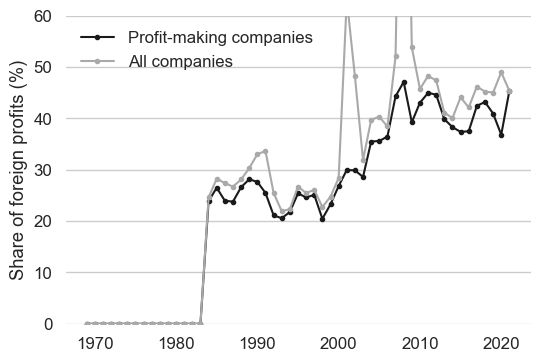

In [ ]:
sns.set(font_scale=1.1,style="whitegrid")

plt.figure(figsize=(6,4))
compustat["n"] = compustat["pifo"] != 0


c = compustat.loc[(compustat["pi"]>0)].dropna(subset=["pi","pifo"]).groupby("year")[["pi","pifo","n"]].sum() #9wxfhizigwvu4lhr
c["share_fo"] = c["pifo"]/c["pi"]
c1 = c.copy()#loc[1984:]
# sns.regplot(np.array(c.index),100*c.share_fo,color="k",lowess=True,label="Profit-making companies",scatter_kws={"s":20})
plt.plot(np.array(c1.index),100*c1.share_fo,".-",color="k",label="Profit-making companies")
compustat["n_total"] = 1

compustat["pi_winsor"] = winsorize(compustat["pi"],[0.01,0.01])

c = compustat.dropna(subset=["pi","pifo"]).groupby("year")[["pi_winsor","pi","pifo","n","n_total"]].sum() #9wxfhizigwvu4lhr
c["share_fo"] = c["pifo"]/c["pi"]
c2 = c.copy()#loc[1984:]


plt.plot(np.array(c2.index),100*c2.share_fo,".-",color="darkgray",label="All companies")
# sns.regplot(np.array(c.index),100*c.share_fo,color="darkgray",lowess=True,label="All companies",scatter_kws={"s":20})
plt.ylim(0,60)
sns.despine(bottom=True,left=True)
plt.gca().grid(axis='x')
plt.ylabel("Share of foreign profits (%)")
plt.legend(frameon=False,loc=2)





c =  pd.concat([c1,c2],axis=1)
c.columns = ["Profit (+)","For. profits (+)","N (positive for. profits) (+)","Share foreign (+)","Profit (winsorized)","Profit (all)","For. profits (all)","N (for. profits) (all)","N (total companies)","Share foreign (all)"]

c["Share N (for. profits, +)"] = c["N (positive for. profits) (+)"]/c["N (total companies)"]
c["Share N (for. profits, all)"] = c["N (for. profits) (all)"]/c["N (total companies)"]

c.to_excel("data/compustat_share_foreign.xlsx")
c

In [32]:
vars_reg = ["pifo","pi","at","revt","intan","nopi","emp","txfo"]
compustat.replace(0,np.nan).groupby("year")[vars_reg].count()

# NOPI -- Nonoperating Income (Expense)

,pifo,pi,at,revt,intan,nopi,emp,txfo
year,,,,,,,,
1969,0,14,14,14,4,12,14,4
1970,0,100,100,100,51,94,100,58
1971,0,121,121,121,58,113,121,73
1972,0,169,169,169,90,157,167,120
1973,0,231,231,231,130,219,228,176
1974,0,292,292,292,152,276,287,216
1975,0,315,315,315,157,299,309,232
1976,0,350,350,350,166,333,341,259
1977,0,382,382,382,185,358,377,274


In [ ]:
compustat.year = compustat.year.astype(np.int64)
comp = compustat.copy()#set_index(["guo","year"])

In [ ]:
for var in vars_reg:
    comp[f"ln{var}"] = np.log(1+comp[var])
    print(var,comp[f"ln{var}"].count())


pifo 34599
pi 38880
at 45870
revt 45874
intan 42628
nopi 38071
emp 44400
txfo 44078


/Users/garci061/miniforge3/envs/st/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/garci061/miniforge3/envs/st/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/garci061/miniforge3/envs/st/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/garci061/miniforge3/envs/st/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [35]:
comp[[f"ln{var}" for var in vars_reg]].corr()

,lnpifo,lnpi,lnat,lnrevt,lnintan,lnnopi,lnemp,lntxfo
lnpifo,1.000000,0.311809,0.301598,0.281292,0.403371,0.218192,0.200120,0.983715
lnpi,0.311809,1.000000,0.734818,0.691099,0.170916,0.188617,0.276073,0.292356
lnat,0.301598,0.734818,1.000000,0.789812,0.211765,0.081882,0.244886,0.272894
lnrevt,0.281292,0.691099,0.789812,1.000000,0.212319,0.166832,0.438952,0.261463
lnintan,0.403371,0.170916,0.211765,0.212319,1.000000,0.027541,0.088410,0.327158
lnnopi,0.218192,0.188617,0.081882,0.166832,0.027541,1.000000,0.124950,0.194158
lnemp,0.200120,0.276073,0.244886,0.438952,0.088410,0.124950,1.000000,0.214470
lntxfo,0.983715,0.292356,0.272894,0.261463,0.327158,0.194158,0.214470,1.000000


In [38]:

comp.dropna(subset=["lnat","lnrevt","lnintan","lnemp","lntxfo"]).groupby("year")[vars_reg].count()

# NOPI -- Nonoperating Income (Expense)

,pifo,pi,at,revt,intan,nopi,emp,txfo
year,,,,,,,,
1969,9,13,13,13,13,13,13,13
1970,41,97,97,97,97,97,97,97
1971,47,119,119,119,119,119,119,119
1972,48,162,162,162,162,162,162,162
1973,52,219,219,219,219,219,219,219
1974,70,270,270,270,270,270,270,270
1975,76,287,287,287,287,287,287,287
1976,82,315,315,315,315,315,315,315
1977,99,346,346,346,346,346,346,346


In [ ]:
## Impute missing data
import statsmodels.formula.api as smf
mod = smf.ols(formula='lnpifo ~  lnat + lnrevt + lnintan + lnemp + lntxfo + C(year)', data=comp)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 lnpifo   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                 1.594e+04
Date:                Wed, 23 Nov 2022   Prob (F-statistic):               0.00
Time:                        12:07:40   Log-Likelihood:                -57895.
No. Observations:               30362   AIC:                         1.159e+05
Df Residuals:                   30304   BIC:                         1.164e+05
Df Model:                          57                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0619      0.576     

In [ ]:
# Predicted
comp["pifo_pred"] = np.exp(res.predict(comp))

In [ ]:
# Impute when missing
comp["pifo_fix"] = comp["pifo"].copy()
comp.loc[np.isnan(comp["pifo"]),"pifo_fix"] = comp.loc[np.isnan(comp["pifo"]),"pifo_pred"]
comp["pidom_fix"] = comp["pi"]-comp["pifo_fix"]

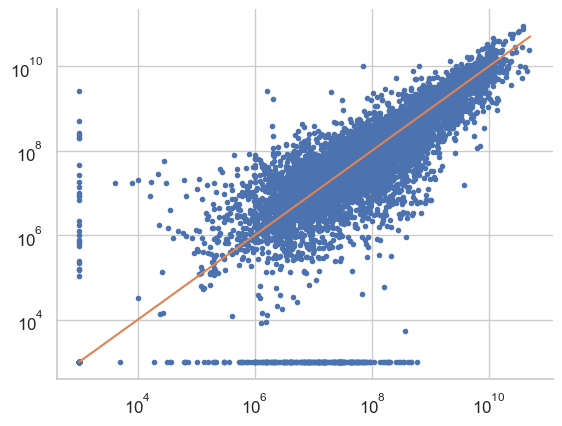

In [44]:
plt.plot(comp["pifo"]+1E3,1E3+comp["pifo_pred"],".")
plt.plot([1E3,5E10],[1E3,5E10])
plt.xscale("log")
plt.yscale("log")
sns.despine()

In [48]:
#To crea9e the excel file
var = "pifo"
a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]
a[var] = (a[var]/1E9)
a.applymap(lambda x: f"{x:2,.0f}").loc[[2016,2017,2018,2019]]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3710697435.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]


,pifo,n_groups
year,,
2016,450,"1,311"
2017,551,"1,324"
2018,617,"1,341"
2019,560,"1,320"


In [49]:
#To crea9e the excel file
var = "pifo_fix"
a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]
a[var] = (a[var]/1E9)
a.applymap(lambda x: f"{x:2,.0f}").loc[[2016,2017,2018,2019]]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/1109892239.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]


,pifo_fix,n_groups
year,,
2016,475,"1,412"
2017,582,"1,426"
2018,644,"1,446"
2019,590,"1,427"


In [50]:
#To crea9e the excel file
var = "pidom"
a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]
a[var] = (a[var]/1E9)
a.applymap(lambda x: f"{x:2,.0f}").loc[[2016,2017,2018,2019]]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/676353341.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]


,pidom,n_groups
year,,
2016,618,"1,311"
2017,641,"1,324"
2018,747,"1,341"
2019,683,"1,320"


In [51]:
#To crea9e the excel file
var = "pidom_fix"
a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]
a[var] = (a[var]/1E9)
a.applymap(lambda x: f"{x:2,.0f}").loc[[2016,2017,2018,2019]]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/1841716205.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]


,pidom_fix,n_groups
year,,
2016,718,"1,412"
2017,749,"1,426"
2018,840,"1,446"
2019,892,"1,427"


In [52]:
#To crea9e the excel file
var = "pi"
a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]
a[var] = (a[var]/1E9)
a.applymap(lambda x: f"{x:2,.0f}").loc[[2016,2017,2018,2019,2020]]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/720046939.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = comp.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]


,pi,n_groups
year,,
2016,"1,204","1,429"
2017,"1,342","1,442"
2018,"1,491","1,461"
2019,"1,489","1,439"
2020,973,"1,378"


In [53]:
comp["flag_mis"] = np.isnan(comp["pifo"])
comp.groupby("flag_mis").mean()[vars_reg+["pifo_pred"]]/1E9

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/20854223.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  comp.groupby("flag_mis").mean()[vars_reg+["pifo_pred"]]/1E9


,pifo,pi,at,revt,intan,nopi,emp,txfo,pifo_pred
flag_mis,,,,,,,,,
False,0.254516,0.615367,15.129245,7.413845,2.021134,0.055792,0.028779,0.071021,0.294180
True,NaN,0.593163,13.849253,6.461866,1.250011,0.060948,0.037121,0.068610,0.195666


In [55]:
comp_short = comp.loc[comp["year"].isin([2015,2016,2018,2019])]
#Exclude guos with losses in one year
comp_short["pi_guo"] = comp_short.groupby("guo")["pi"].transform(np.min)
comp_short_pos = comp_short.loc[comp_short["pi_guo"]>0]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3063445133.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comp_short["pi_guo"] = comp_short.groupby("guo")["pi"].transform(np.min)


In [56]:
a1 = comp_short.groupby("year").sum()
a1 = a1["txc"]/a1["pi"]
a1.loc[2015:]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/2527442073.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a1 = comp_short.groupby("year").sum()


year
2015    0.304677
2016    0.253233
2018    0.226140
2019    0.188501
dtype: float64

In [58]:
a1 = comp_short_pos.groupby("year").sum()
a1 = a1["txc"]/a1["pi"]
a1.loc[2015:]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/1165489915.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a1 = comp_short_pos.groupby("year").sum()


year
2015    0.244315
2016    0.224239
2018    0.212568
2019    0.164329
dtype: float64

In [59]:
#To crea9e the excel file

a = comp.dropna(subset=["pidom_fix"]).groupby("year").sum()[["pidom","pidom_fix","pi","pifo_fix","pifo"]]
a["share_foreign"] = a["pifo"]/a["pi"]
a["share_foreign_fix"] = a["pifo_fix"]/a["pi"]
a.to_excel("./data/compustat_profits_fixed_by_year.xlsx")
a

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/383239684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = comp.dropna(subset=["pidom_fix"]).groupby("year").sum()[["pidom","pidom_fix","pi","pifo_fix","pifo"]]


,pidom,pidom_fix,pi,pifo_fix,pifo,share_foreign,share_foreign_fix
year,,,,,,,
1969,1.378712e+09,1.708711e+09,1.816020e+09,1.073088e+08,0.000000e+00,0.000000,0.059090
1970,7.763976e+09,1.406633e+10,1.874804e+10,4.681705e+09,0.000000e+00,0.000000,0.249717
1971,8.972441e+09,1.648889e+10,2.615516e+10,9.666275e+09,0.000000e+00,0.000000,0.369574
1972,9.918921e+09,2.702504e+10,4.139954e+10,1.437449e+10,0.000000e+00,0.000000,0.347214
1973,1.155154e+10,3.838158e+10,6.070817e+10,2.232659e+10,0.000000e+00,0.000000,0.367769
1974,1.407735e+10,3.854903e+10,7.666280e+10,3.811377e+10,0.000000e+00,0.000000,0.497161
1975,1.632621e+10,3.974204e+10,7.531700e+10,3.557496e+10,0.000000e+00,0.000000,0.472336
1976,2.034137e+10,5.625552e+10,1.000057e+11,4.375014e+10,0.000000e+00,0.000000,0.437477
1977,2.609430e+10,6.561751e+10,1.150782e+11,4.946067e+10,0.000000e+00,0.000000,0.429801


In [60]:
#To crea9e the excel file
var = "pifo"
a = compustat.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]
a[var] = (a[var]/1E9)
a.applymap(lambda x: f"{x:2,.0f}").loc[[2016,2017,2018,2019]]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/2085588891.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = compustat.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]


,pifo,n_groups
year,,
2016,450,"1,311"
2017,551,"1,324"
2018,617,"1,341"
2019,560,"1,320"


In [61]:
#To crea9e the excel file
var = "pi"
a = compustat.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]
a[var] = (a[var]/1E9)
a.applymap(lambda x: f"{x:2,.0f}").loc[[2016,2017,2018,2019]]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3488603693.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = compustat.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]


,pi,n_groups
year,,
2016,"1,204","1,429"
2017,"1,342","1,442"
2018,"1,491","1,461"
2019,"1,489","1,439"


In [ ]:
# BAlanced sample
compustat_balanced = compustat.dropna(subset=["txc","txfo","pi","pifo","revt","emp"])

In [63]:
#To create the excel file
var = "txdom"
a = compustat_balanced.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]
a[var] = (a[var]/1E9)
a.applymap(lambda x: f"{x:2,.0f}")

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/4134609818.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = compustat_balanced.dropna(subset=[var]).groupby("year").sum()[[var,"n_groups"]]


,txdom,n_groups
year,,
1969,1,10
1970,1,38
1971,1,42
1972,3,46
1973,3,53
1974,3,73
1975,2,79
1976,4,83
1977,5,101


In [64]:
#Also for the excel file
cbcr_all["dom"] = cbcr_all["iso"]=="USA"
a = cbcr_all.groupby(["type","dom","year",]).sum()/1E3
a["n_groups"]*=1E9
a.rename(columns={"txt":"tax_accrued", "txc":"tax_paid"}).applymap(lambda x: f"{x:2,.0f}").loc["all_groups"]


/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/1510576074.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  a = cbcr_all.groupby(["type","dom","year",]).sum()/1E3


n_groups revenue_unrelated revenue_related   revenue_total  \
dom   year                                                                     
False 2016  26,557,000,000     6,879,434,159   4,613,547,609  11,492,981,768   
      2017  33,435,000,000     9,201,811,987   6,074,358,764  15,276,170,750   
      2018  34,311,000,000    10,094,871,712   6,633,920,797  16,728,792,509   
      2019  35,527,000,000    10,062,366,084   6,547,833,211  16,610,199,295   
True  2016   1,017,000,000     7,799,962,588   2,718,649,216  10,518,611,805   
      2017   1,487,000,000    10,617,982,421   3,303,975,479  13,921,957,900   
      2018   1,568,000,000    11,323,655,145   3,418,412,407  14,742,067,553   
      2019   1,627,000,000    11,679,730,842   3,496,628,029  15,176,358,871   

                       pi     tax_paid  tax_accrued         capital  \
dom   year                                                            
False 2016  1,105,320,932  172,500,387  155,167,338  21,136,165,893   
      2017  1,684,076,656  219,698,154  226,529,623  25,750,249,487   
      2018  2,231,570,144  241,777,068  240,263,838  26,526,356,293   
      2019  1,866,901,410  250,568,982  256,461,397  27,061,620,907   
True  2016    867,852,046  176,579,355  185,540,113  11,807,553,304   
      2017  1,179,985,562  212,807,567  262,772,826  14,760,861,137   
      2018  1,488,466,473  140,614,147  223,128,621  14,778,275,047   
      2019  1,295,596,596  203,694,032  165,944,553  15,339,861,226   

           accum_earnings     emp           t_at          wages  
dom   year                                                       
False 2016  7,760,087,563  22,353  3,984,872,659    243,795,325  
      2017  9,862,436,412  28,331  5,540,801,022    293,924,202  
      2018  7,833,286,897  32,607  5,286,443,932    339,818,673  
      2019  8,158,220,332  29,820  4,464,554,189    308,564,806  
True  2016  7,383,423,718  16,377  4,223,574,794    797,122,614  
      2017  8,357,736,769  22,903  5,538,478,604  1,114,757,351  
      2018  8,212,734,719  23,742  5,981,684,597  1,155,569,505  
      2019  9,565,197,540  23,958  5,871,941,486  1,166,089,422

## 1.5 BEA (Profit-type return) 
--> Part II https://www.bea.gov/data/intl-trade-investment/activities-us-multinational-enterprises-mnes
--> Domestic: All U.S. Parents
--> Foreing: Info on tables A (some summaries, also available on other tables), D (foreign taxes, ect) and F (profit-type return)

-->  Income without current-cost adjustment: https://www.bea.gov/international/di1usdbal

### Foreign

In [20]:

def filter_sheet(filename,sheet_name,colnames=[],year=2016,skiprows=4,keepcols=None,var=None,start=0):
    bea = pd.read_excel(filename,
                        sheet_name=sheet_name,skiprows=skiprows)
    if keepcols is not None:
        bea.columns = range(len(bea.columns))
        bea = bea.loc[:,keepcols]
        
        if len(colnames) > 0:
             bea.columns = colnames
        
        bea["year"] = year
        
    else:
        bea.columns = colnames
        bea["year"] = year
    

    if "country" in colnames:
        cs_unique = ["Other"]
        d_cs_unique = {"Other": start}
        new_cs = []
        for c in bea["country"]:
            if isinstance(c,str):
                if c in cs_unique:
                    d_cs_unique[c] += 1
                    c =  f"{c}{d_cs_unique[c]}"
                    
                else:
                    cs_unique.append(c)
                    d_cs_unique[c] = start
                
            new_cs.append(c)
        bea["country"] = new_cs
    
    if var is not None:
        bea = bea.dropna(subset=["sector"])
        bea["sector"] = bea["sector"].str.strip()
        sectors = ["Mining","Manufacturing","Wholesale trade","Retail trade","Information","Finance and insurance","Professional, scientific, and technical services","Other industries"]
        bea["sector"] = bea["sector"].replace("Finance (except depository institutions) and insurance","Finance and insurance")
        bea = bea.loc[bea["sector"].str.strip().str.len() > 1]
        bea = bea.loc[bea["sector"].str.strip() != "Other"]
        bea = bea.dropna(subset=["sector"])
        bea = bea.set_index(["sector","year"]).loc[:,var]    

    return bea


def basic_bea_cleaning(bea_revenue,endfile="bea_revenue.csv"):
    bea_revenue = bea_revenue.dropna(subset=["country"])
    #delete periods at the end
    bea_revenue["country"] = bea_revenue["country"].str.replace("\.\.+$","")
    bea_revenue["country"] = bea_revenue["country"].str.strip()
    for col in bea_revenue.columns:
        bea_revenue[col] = bea_revenue[col].apply(lambda x: x.strip().replace(",","") if isinstance(x,str) else x)
    
    bea_revenue["iso"] = bea_revenue["country"].apply(get_iso3,print_failure=False)
    #print(set([_ for _ in bea_revenue["country"] if name2iso2.get(_) is None]))
    bea_revenue = bea_revenue.dropna(subset=["iso"]) 
    bea_revenue.to_csv("data/{}".format(endfile),sep="\t",index=None)
    bea_revenue = pd.read_csv("data/{}".format(endfile),sep="\t",keep_default_na=False,
                          na_values=['','M', '(D)', 'A', 'G', 'K', 'J', '(*)', 'X', 'I', 'H', 'L', 'F'])
    
    bea_revenue.to_csv("data/{}".format(endfile),sep="\t",index=None)



def format_real_income(sheet):
    df = pd.read_excel("data_raw/BEA_net_income/usdia-income-121.xlsx",skiprows=2,sheet_name=str(sheet))
    df.columns = range(len(df.columns))
    df = df.loc[:,[0,1]]
    df.columns = ["country","real_income"]
    
    df["country"] = df["country"].str.strip()

    cs_unique = ["Other"]
    d_cs_unique = {"Other": 0}
    new_cs = []
    for c in df["country"]:
        if isinstance(c,str):
            if c in cs_unique:
                d_cs_unique[c] += 1
                c =  f"{c}{d_cs_unique[c]}"

            else:
                cs_unique.append(c)
                d_cs_unique[c] = 0

        new_cs.append(c)
    df["country"] = new_cs
        
    df["iso"] = df["country"].apply(get_iso3,print_failure=False)
    df = df.dropna(subset=["iso"])
    df = df.infer_objects()
    df["real_income"] *= 1E6
    df = df[["iso","real_income"]]
    df["year"] = sheet
    return df
    
    
def extract_bea_kimberly(path_bea="data_raw/BEA/"):
    colnames = ["country","n_forms","at","t_at","capital_exp","revenue_total","income","va","rd","wages","emp"]
    b21a = filter_sheet(f"{path_bea}usdia-2021r-excel/Part-II-A1-A2.xls","Table II. A 1(1)",colnames,2021)
    b21b = filter_sheet(f"{path_bea}usdia-2021r-excel/Part-II-A1-A2.xls","Table II. A 1(2)",colnames,2021,start=10)
    b20a = filter_sheet(f"{path_bea}usdia-2020r-excel/Part-II-A1-A2.xls","Table II. A 1(1)",colnames,2020)
    b20b = filter_sheet(f"{path_bea}usdia-2020r-excel/Part-II-A1-A2.xls","Table II. A 1(2)",colnames,2020,start=10)
    b19a = filter_sheet(f"{path_bea}usdia-2019r-excel/PartII-A1-A4.xls","Table II. A 1(1)",colnames+["n_pars"],2019)
    b19b = filter_sheet(f"{path_bea}usdia-2019r-excel/PartII-A1-A4.xls","Table II. A 1(2)",colnames+["n_pars"],2019,start=10)
    b18a = filter_sheet(f"{path_bea}usdia-2018r-excel/Part-II-A1-A2.xls","Table II. A 1(1)",colnames,2018)
    b18b = filter_sheet(f"{path_bea}usdia-2018r-excel/Part-II-A1-A2.xls","Table II. A 1(2)",colnames,2018,start=10)
    b17a = filter_sheet(f"{path_bea}usdia-2017r-excel/Part-II-A1-A2.xls","Table II. A 1(1)",colnames,2017)
    b17b = filter_sheet(f"{path_bea}usdia-2017r-excel/Part-II-A1-A2.xls","Table II. A 1(2)",colnames,2017,start=10)
    b16a = filter_sheet(f"{path_bea}usdia-2016r-excel/Part-II-A1-A2.xls","Table II. A 1(1)",colnames,2016)
    b16b = filter_sheet(f"{path_bea}usdia-2016r-excel/Part-II-A1-A2.xls","Table II. A 1(2)",colnames,2016,start=10)
    b15a = filter_sheet(f"{path_bea}2015-combined-tables/Part II A1-A2.xls","Table II. A 1(1)",colnames,2015)
    b15b = filter_sheet(f"{path_bea}2015-combined-tables/Part II A1-A2.xls","Table II. A 1(2)",colnames,2015,start=10)
    
    colnames = ["country","n_forms","at","t_at","capital_exp","revenue_total","income","va","rd","wages","emp","fdi","fdi_income","n_groups"]
    b14a = filter_sheet(f"{path_bea}2014-combined-forms/PartII-A1-A2.xls","Table II. A 1(1)",colnames,2014)
    b14b = filter_sheet(f"{path_bea}2014-combined-forms/PartII-A1-A2.xls","Table II. A 1(2)",colnames,2014,start=10)

    colnames = ["country","n_forms","at","t_at","capital_exp","revenue_total","income","va","rd","wages","emp"]
    b13 = filter_sheet(f"{path_bea}usdia_2013r_excel(1)/Part II A1-A2 .xls","Table II. A 1",colnames,2013)
    b12 = filter_sheet(f"{path_bea}usdia_2012r_excel(1)/Part II A1-A2 .xls","Table II.A 1",colnames,2012)
    b11 = filter_sheet(f"{path_bea}usdia_2011r_excel(1)/Part II A1-A2 .xls","II.A 1",colnames,2011)
    b10 = filter_sheet(f"{path_bea}usdia_2010r_excel/Part II A1-A2 .xls","II.A 1",colnames,2010)

    colnames = ["country","n_forms","at","t_at","capital_exp","revenue_total","income","va","rd","wages","emp","fdi","fdi_income","n_groups"]
    b09 = filter_sheet(f"{path_bea}usdia_2009r_excel/Part II A1-A2 .xls","II.A 1",colnames,2009)
    
    colnames = ["country","n_forms","at","revenue_total","income","wages","emp"]
    b08 = filter_sheet(f"{path_bea}USDIA_08R/Tab2A1.xls","TablePage",colnames,2008)
    b07 = filter_sheet(f"{path_bea}USDIA2007revised/Tab2A1_new.xls","TablePage",colnames,2007)
    b06 = filter_sheet(f"{path_bea}USDIA2006revised/Tab2A1.xls","TablePage",colnames,2006)
    b05 = filter_sheet(f"{path_bea}USDIA2005revised/Tab2A1.xls","Sheet1",colnames,2005)
    
    colnames = ["country","n_forms","at","t_at","revenue_total","income","wages","emp","fdi","fdi_income","n_groups"]
    b04 = filter_sheet(f"{path_bea}usdia2004revised/Tab2A1.xls","TablePage",colnames,2004)

    
    bea_tableA = pd.concat([b21a, b21b, b20a,b20b,b19a,b19b,b18a,b18b,b17a,b17b,b16a,b16b,b15a,b15b,b14a,b14b,b13,b12,b11,b10,b09,b08,b07,b06,b05,b04]).dropna(subset=["country"])
    
    keepcols = [0,3,4]
    colnames = ['country','profit_return','net_interest']
    b21a = filter_sheet(f"{path_bea}usdia-2021r-excel/Part-II-F1-F9.xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2021)
    b21b = filter_sheet(f"{path_bea}usdia-2021r-excel/Part-II-F1-F9.xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2021,start=10)
    b20a = filter_sheet(f"{path_bea}usdia-2020r-excel/Part-II-F1-F9.xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2020)
    b20b = filter_sheet(f"{path_bea}usdia-2020r-excel/Part-II-F1-F9.xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2020,start=10)
    b19a = filter_sheet(f"{path_bea}usdia-2019r-excel/PartII-F1-F9.xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2019)
    b19b = filter_sheet(f"{path_bea}usdia-2019r-excel/PartII-F1-F9.xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2019,start=10)
    b18a = filter_sheet(f"{path_bea}usdia-2018r-excel/Part-II-F1-F9.xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2018)
    b18b = filter_sheet(f"{path_bea}usdia-2018r-excel/Part-II-F1-F9.xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2018,start=10)
    b17a = filter_sheet(f"{path_bea}usdia-2017r-excel/Part-II-F1-F9.xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2017)
    b17b = filter_sheet(f"{path_bea}usdia-2017r-excel/Part-II-F1-F9.xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2017,start=10)
    b16a = filter_sheet(f"{path_bea}usdia-2016r-excel/Part-II-F1-F9.xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2016)
    b16b = filter_sheet(f"{path_bea}usdia-2016r-excel/Part-II-F1-F9.xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2016,start=10)
    b15a = filter_sheet(f"{path_bea}2015-combined-tables/Part II F1-F9.xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2015)
    b15b = filter_sheet(f"{path_bea}2015-combined-tables/Part II F1-F9.xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2015,start=10)
    

    b14a = filter_sheet(f"{path_bea}2014-combined-forms/PartII-F1-F9.xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2014)
    b14b = filter_sheet(f"{path_bea}2014-combined-forms/PartII-F1-F9.xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2014,start=10)
    b13a = filter_sheet(f"{path_bea}usdia_2013r_excel(1)/Part II F1-F9 .xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2013)
    b13b = filter_sheet(f"{path_bea}usdia_2013r_excel(1)/Part II F1-F9 .xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2013,start=10)
    b12a = filter_sheet(f"{path_bea}usdia_2012r_excel(1)/Part II F1-F9 .xls","Table II.F 1",keepcols=keepcols,colnames=colnames,year=2012)
    b12b = filter_sheet(f"{path_bea}usdia_2012r_excel(1)/Part II F1-F9 .xls","Table II.F 2",keepcols=keepcols,colnames=colnames,year=2012,start=10)
    b11a = filter_sheet(f"{path_bea}usdia_2011r_excel(1)/Part II F1-F9 .xls","II.F 1",keepcols=keepcols,colnames=colnames,year=2011)
    b11b = filter_sheet(f"{path_bea}usdia_2011r_excel(1)/Part II F1-F9 .xls","II.F 2",keepcols=keepcols,colnames=colnames,year=2011,start=10)
    b10a = filter_sheet(f"{path_bea}usdia_2010r_excel/Part II F1-F9 .xls","II.F 1",keepcols=keepcols,colnames=colnames,year=2010)
    b10b = filter_sheet(f"{path_bea}usdia_2010r_excel/Part II F1-F9 .xls","II.F 2",keepcols=keepcols,colnames=colnames,year=2010,start=10)

    b09 = filter_sheet(f"{path_bea}usdia_2009r_excel/Part II F1-F9 .xls","II.F 1",keepcols=keepcols,colnames=colnames,year=2009)
    b08 = filter_sheet(f"{path_bea}USDIA_08R/Tab3G1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2008)
    b07 = filter_sheet(f"{path_bea}USDIA2007revised/Tab3G1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2007)
    b06 = filter_sheet(f"{path_bea}USDIA2006revised/Tab3G1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2006)
    b05 = filter_sheet(f"{path_bea}USDIA2005revised/Tab3G1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2005)
    b04 = filter_sheet(f"{path_bea}usdia2004revised/Tab3G1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2004)

    bea_tableF = pd.concat([b21a, b21b, b20a,b20b,b19a,b19b,b18a,b18b,b17a,b17b,b16a,b16b,b15a,b15b,b14a,b14b,b13a,b13b,b12a,b12b,b11a,b11b,b10a,b10b,b09,b08,b07,b06,b05,b04]).dropna(subset=["country"])                        
    
    def convert_float(x):
        try:
            return float(x)
        except:
            return np.nan
    #For every year we need to add foreign taxes (table D)
    keepcols = [0,3,4,8]
    colnames = ['country','income_equity','capital_gains',"txt"]
    keepcols_19r = [0,3,4,5,9]
    colnames_19r = ['country','income_equity1','income_equity2','capital_gains',"txt"]
    b21ft = filter_sheet(f"{path_bea}usdia-2021r-excel/Part-II-D1-D13.xls","Table II.D 1",keepcols=keepcols,colnames=colnames,year=2021)
    b20ft = filter_sheet(f"{path_bea}usdia-2020r-excel/Part-II-D1-D13.xls","Table II.D 1",keepcols=keepcols,colnames=colnames,year=2020)
    b19ft = filter_sheet(f"{path_bea}usdia-2019r-excel/PartII-D1-D13.xls","Table II.D 1",keepcols=keepcols_19r,colnames=colnames_19r,year=2019)
    b19ft["income_equity"] = b19ft["income_equity1"].apply(convert_float) + b19ft["income_equity2"].apply(convert_float)
    b18ft = filter_sheet(f"{path_bea}usdia-2018r-excel/Part-II-D1-D13.xls","Table II.D 1",keepcols=keepcols,colnames=colnames,year=2018)
    b17ft = filter_sheet(f"{path_bea}usdia-2017r-excel/Part-II-D1-D13.xls","Table II.D 1",keepcols=keepcols,colnames=colnames,year=2017)
    b16ft = filter_sheet(f"{path_bea}usdia-2016r-excel/Part-II-D1-D13.xls","Table II.D 1",keepcols=keepcols,colnames=colnames,year=2016)
    b15ft = filter_sheet(f"{path_bea}2015-combined-tables/Part II D1-D13.xls","Table II.D 1",keepcols=keepcols,colnames=colnames,year=2015)
    b13ft = filter_sheet(f"{path_bea}usdia_2013r_excel(1)/Part II D1-D13 .xls","Table II.D 1",keepcols=keepcols,colnames=colnames,year=2013)
    b12ft = filter_sheet(f"{path_bea}usdia_2012r_excel(1)/Part II D1-D13 .xls","Table II.D 1",keepcols=keepcols,colnames=colnames,year=2012)
    b11ft = filter_sheet(f"{path_bea}usdia_2011r_excel(1)/Part II D1-D13 .xls","II.D 1",keepcols=keepcols,colnames=colnames,year=2011)
    b10ft = filter_sheet(f"{path_bea}usdia_2010r_excel/Part II D1-D13 .xls","II.D 1",keepcols=keepcols,colnames=colnames,year=2010)
    b08ft = filter_sheet(f"{path_bea}USDIA_08R/Tab3E1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2008)
    b07ft = filter_sheet(f"{path_bea}USDIA2007revised/Tab3E1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2007)
    b06ft = filter_sheet(f"{path_bea}USDIA2006revised/Tab3E1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2006)
    b05ft = filter_sheet(f"{path_bea}USDIA2005revised/Tab3E1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2005)

    
    keepcols = [0,2,3,4,9]
    colnames = ['country','_','income_equity','capital_gains',"txt"]
    b14ft = filter_sheet(f"{path_bea}2014-combined-forms/PartII-D1-D13.xls","Table II.D 1",keepcols=keepcols,colnames=colnames,year=2014)
    b09ft = filter_sheet(f"{path_bea}usdia_2009r_excel/Part II D1-D13 .xls","II.D 1",keepcols=keepcols,colnames=colnames,year=2009)
    b04ft = filter_sheet(f"{path_bea}usdia2004revised/Tab3E1.xls","TablePage",keepcols=keepcols,colnames=colnames,year=2004)
    
    
    #data on foreign taxes
    bea_ft = pd.concat([b21ft, b20ft,b19ft,b18ft,b17ft,b16ft,b15ft,b14ft,b13ft,b12ft,b11ft,b10ft,b09ft,b08ft,b07ft,b06ft,b05ft,b04ft]).dropna(subset=["country"])
    
    
    #Add unrelated sales (II E.2 for foreign)
    keepcols = [0,3,4,7,8,10,11]
    colnames = ['country','us_related_sales','us_unrelated_sales',"for1_relates_sales","for1_unrelates_sales","for2_relates_sales","for2_unrelates_sales"]
    b21ft = filter_sheet(f"{path_bea}usdia-2021r-excel/Part-II-E1-E17.xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2021)
    b20ft = filter_sheet(f"{path_bea}usdia-2020r-excel/Part-II-E1-E17.xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2020)
    b19ft = filter_sheet(f"{path_bea}usdia-2019r-excel/PartII-E1-E18.xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2019)
    b18ft = filter_sheet(f"{path_bea}usdia-2018r-excel/Part-II-E1-E17.xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2018)
    b17ft = filter_sheet(f"{path_bea}usdia-2017r-excel/Part-II-E1-E17.xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2017)
    b16ft = filter_sheet(f"{path_bea}usdia-2016r-excel/Part-II-E1-E17.xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2016)
    b15ft = filter_sheet(f"{path_bea}2015-combined-tables/Part II E1-E17.xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2015)
    b14ft = filter_sheet(f"{path_bea}2014-combined-forms/PartII-E1-E18.xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2014)
   
    keepcols = [0,5,6,11,12,14,15]
    b13ft = filter_sheet(f"{path_bea}usdia_2013r_excel(1)/Part II E1-E17 .xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2013)
    b12ft = filter_sheet(f"{path_bea}usdia_2012r_excel(1)/Part II E1-E17 .xls","Table II.E 2",keepcols=keepcols,colnames=colnames,year=2012)
    b11ft = filter_sheet(f"{path_bea}usdia_2011r_excel(1)/Part II E1-E17 .xls","II.E 2",keepcols=keepcols,colnames=colnames,year=2011)
    b10ft = filter_sheet(f"{path_bea}usdia_2010r_excel/Part II E1-E17 .xls","II.E 2",keepcols=keepcols,colnames=colnames,year=2010)
    
    #data on foreign taxes
    bea_sales = pd.concat([b21ft, b20ft, b19ft,b18ft,b17ft,b16ft,b15ft,b14ft,b13ft,b12ft,b11ft,b10ft]).dropna(subset=["country"])
    

    bea_revenue = pd.merge(bea_tableA,bea_tableF,on=["country","year"],how="outer")
    bea_revenue = pd.merge(bea_revenue,bea_ft,on=["country","year"],how="outer")
    bea_revenue = pd.merge(bea_revenue,bea_sales,on=["country","year"],how="outer")
    
    return bea_revenue    

In [21]:
# if "usdia-income.xlsx" not in "data_raw/BEA_net_income":
#     wget.download("https://www.bea.gov/system/files/2021-03/usdia-income-420.xlsx","data_raw/BEA_net_income/usdia-income.xlsx")
        #https://www.bea.gov/system/files/2021-06/usdia-income-121.xlsx

In [22]:
#Income without current cost adjustment
real_income = pd.concat([format_real_income(sheet) for sheet in range(2004,2021)])
real_income.head()


,iso,real_income,year
0,Rest,2.281650e+11,2004
2,CAN,2.283500e+10,2004
6,AUT,6.310000e+08,2004
7,BEL,3.305000e+09,2004
8,CZE,3.560000e+08,2004


In [23]:
#Data on foreign profits
bea_revenue_kim = extract_bea_kimberly()   
bea_revenue_kim.loc[bea_revenue_kim["country"].str.contains("Other\d")].head(20)

,country,n_forms,at,t_at,capital_exp,revenue_total,income,va,rd,wages,emp,year,n_pars,fdi,fdi_income,n_groups,profit_return,net_interest,income_equity,capital_gains,txt,income_equity1,income_equity2,_,us_related_sales,us_unrelated_sales,for1_relates_sales,for1_unrelates_sales,for2_relates_sales,for2_unrelates_sales
3274,Other1,261,51903,17335,NaN,22970,5604,NaN,NaN,1818,120.9,2004,NaN,10358,1094,202,4229.0,14.0,1221,891,941,NaN,NaN,18891,NaN,NaN,NaN,NaN,NaN,NaN
3275,Other1,267,65052,NaN,NaN,26111,8371,NaN,NaN,1914,125.8,2005,NaN,NaN,NaN,NaN,5773,103,3800,(*),1507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3276,Other1,296,81220,NaN,NaN,34177,12205,NaN,NaN,2012,128.2,2006,NaN,NaN,NaN,NaN,8854,50,4582.0,-23,1522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3277,Other1,324,101448,NaN,NaN,44846,15818,NaN,NaN,2559,138.8,2007,NaN,NaN,NaN,NaN,13599,377,5947.0,-28,3822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3278,Other1,340,113890,NaN,NaN,54661,20118,NaN,NaN,3018,143.3,2008,NaN,NaN,NaN,NaN,16116,711.0,9104.0,-147,5235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3279,Other1,338,144570,32414,4174,41556,11685,17718,(D),3164,139.9,2009,NaN,38670,2615,147,6767,(D),7805,190,2599,NaN,NaN,41556,NaN,NaN,NaN,NaN,NaN,NaN
3280,Other1,354,145617,32582,4284,50148,16833,23528,(D),3308,139.3,2010,NaN,NaN,NaN,NaN,12147,-243,8953,139,(D),NaN,NaN,NaN,(D),(D),712,17317,8232,22452
3281,Other1,373,180172,33399,3867,61698,24549,30547,(D),3483,144.3,2011,NaN,NaN,NaN,NaN,18291,-618,12860,39,6470,NaN,NaN,NaN,(D),(D),(D),18854,(D),30773
3282,Other1,396,221985,33802,4396,58952,26918,29088,(D),3538,148.4,2012,NaN,NaN,NaN,NaN,17328,-954,14822,1042,6103,NaN,NaN,NaN,583,90,(D),(D),(D),(D)
3283,Other1,401,246438,32030,9012,62637,27665,31759,(D),3755,152.1,2013,NaN,NaN,NaN,NaN,19672,-581,12845,(D),(D),NaN,NaN,NaN,(D),(D),(D),(D),(D),(D)


In [24]:
#Data on foreign profits
bea_revenue_kim = extract_bea_kimberly()   
basic_bea_cleaning(bea_revenue_kim,endfile="bea_revenue_kim.csv")
bea_revenue_kim = pd.read_csv("data/bea_revenue_kim.csv",sep="\t")

bea_revenue_kim.head(20)

,country,n_forms,at,t_at,capital_exp,revenue_total,income,va,rd,wages,emp,year,n_pars,fdi,fdi_income,n_groups,profit_return,net_interest,income_equity,capital_gains,txt,income_equity1,income_equity2,_,us_related_sales,us_unrelated_sales,for1_relates_sales,for1_unrelates_sales,for2_relates_sales,for2_unrelates_sales,iso
0,Afghanistan,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,2004,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
1,Afghanistan,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
2,Afghanistan,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
3,Afghanistan,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
4,Afghanistan,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
5,Afghanistan,0.0,4.0,1.0,NaN,8.0,-1.0,NaN,0.0,NaN,NaN,2009,NaN,3.0,-1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
6,Afghanistan,0.0,4.0,1.0,NaN,8.0,-1.0,NaN,0.0,NaN,NaN,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
7,Afghanistan,0.0,4.0,1.0,NaN,8.0,-1.0,NaN,0.0,NaN,NaN,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
8,Afghanistan,0.0,4.0,1.0,NaN,8.0,-1.0,NaN,0.0,NaN,NaN,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
9,Afghanistan,0.0,4.0,1.0,NaN,8.0,-1.0,NaN,0.0,NaN,NaN,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG


In [25]:
bea_revenue_kim.groupby("year")["net_interest"].sum()

year
2004    -27753.0
2005    -52609.0
2006    -43156.0
2007    -29989.0
2008    -16814.0
2009    -81026.0
2010    -81432.0
2011    -85638.0
2012    -78315.0
2013    -68064.0
2014    -88558.0
2015    -97545.0
2016    -88721.0
2017   -115246.0
2018   -110646.0
2019   -125227.0
2020   -112636.0
2021   -111485.0
Name: net_interest, dtype: float64

In [26]:
bea_revenue_kim.loc[bea_revenue_kim["iso"]=="Rest",["year","txt","profit_return","capital_gains"]]

,year,txt,profit_return,capital_gains
54,2004,74068.0,258763.0,7079.0
55,2005,100143.0,324862.0,16815.0
56,2006,114027.0,365201.0,17374.0
57,2007,125181.0,419550.0,6637.0
58,2008,140644.0,449158.0,-51977.0
59,2009,109424.0,398679.0,11676.0
60,2010,130000.0,460173.0,36111.0
61,2011,163878.0,561088.0,12328.0
62,2012,152667.0,543380.0,3219.0
63,2013,138607.0,511726.0,9186.0


In [27]:
bea_revenue_kim.loc[bea_revenue_kim["iso"]=="FRA",["year","txt","profit_return","capital_gains"]]

,year,txt,profit_return,capital_gains
1108,2004,2645.0,8522.0,17.0
1109,2005,2573.0,8431.0,-350.0
1110,2006,2783.0,7425.0,107.0
1111,2007,3556.0,9042.0,1268.0
1112,2008,3266.0,8928.0,199.0
1113,2009,2204.0,5970.0,780.0
1114,2010,3007.0,5197.0,389.0
1115,2011,3457.0,7736.0,-27.0
1116,2012,3352.0,6950.0,-103.0
1117,2013,3457.0,5860.0,-56.0


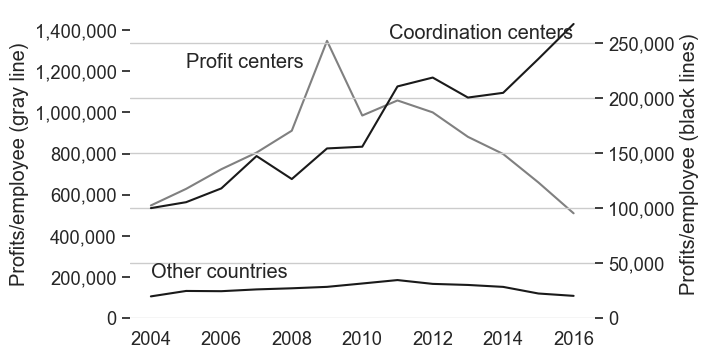

In [ ]:
import matplotlib
#Test for thomas/decom
coord_c = ['NL', 'CH', 'SG', 'IE', 'HK']
coord_c = [get_iso3(_) for _ in coord_c]
profit_c = ['KY', 'BM', 'PR', 'JE', 'BS', 'IM', 'BB', 'GI', 'LU','UK caribbean', 'UK_Caribbean', 
            'BEA_Other_Western', 'VG', 'MU', 'MT', "Other", "Other Europe", "Other2", "Other Central America"]
profit_c = [get_iso3(_,print_failure=False) if _ in name2iso3 else _ for _ in profit_c]

bea_revenue_kim["pi"] = bea_revenue_kim['profit_return']-bea_revenue_kim['net_interest']

var = "emp"
var2 = "pi"

cols_ = []
for g in [var,var2]:
    data =pd.pivot_table(bea_revenue_kim, index="iso",columns="year",values=g)
    data[data<=0] = np.nan
    cols_.append(pd.melt(data.T.ffill().bfill().T.reset_index(),id_vars="iso",value_name=g).set_index(["iso","year"]))
bea_temp = pd.concat(cols_, axis=1).reset_index().dropna()
bea_temp = bea_temp.loc[bea_temp["year"]<=2016]

# bea_temp[bea_temp["pi"]<0,"pi"] = 0
coord  = bea_temp.loc[bea_temp["iso"].isin(coord_c)].groupby("year").sum()
prof  = bea_temp.loc[bea_temp["iso"].isin(profit_c)].groupby("year").sum()
oth  = bea_temp.loc[~bea_temp["iso"].isin(coord_c+profit_c+["USA","Rest"])].groupby("year").sum()

ext = 1000



sns.set(font_scale=1.2, style="white")
plt.figure(figsize=(6,4))

plt.plot(prof.index,prof[var2]/prof[var]*ext,label="Prof",color="gray")
# plt.legend(loc=2)
plt.annotate("Profit centers",(2005,1200*ext),ha="left",va="bottom")
plt.ylim(-0.02,1500*ext)
plt.ylabel("Profits/employee (gray line)")
# plt.yticks(np.round(np.linspace(0,22,8),1))
plt.gca().get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.twinx()

plt.plot(coord.index,coord[var2]/coord[var]*ext,label="Coord",color="k")
plt.plot(oth.index,oth[var2]/oth[var]*ext,label="Other",color="k")
plt.annotate("Coordination centers",(2016,250*ext),ha="right",va="bottom")
plt.annotate("Other countries",(2004,50*ext),ha="left",va="top")
plt.ylabel("Profits/employee (black lines)")
plt.ylim(-0.02,280*ext)
plt.xlabel("Year")
# plt.legend(loc=5)
plt.gca().grid(axis='y')
# plt.yticks([0,0.5,1,1.5,2,2.5,3,3.5])
plt.gca().get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.despine(left=True,bottom=True)


In [30]:
above20 = ['CA', 'AT', 'CZ', 'DK', 'FI', 'FR', 'DE', 'GR', 'HU', 'IT', 'NO', 'PT', 'RU', 'ES', 'TR', 'GB', 'AR', 'BR', 'CL', 'CO', 'EC', 'PE', 'Other0', 'MX', 'PA', 'Other1', 'ZA', 'Other3', 'Other4', 'IN', 'ID', 'JP', 'KR', 'MY', 'NZ', 'PH', 'TW', 'TH', 'CA', 'BE', 'DK', 'FI', 'FR', 'DE', 'GR', 'IT', 'NO', 'PT', 'RU', 'ES', 'TR', 'GB', 'AR', 'BR', 'CL', 'CO', 'EC', 'PE', 'VE', 'Other0', 'HN', 'MX', 'PA', 'Other1', 'ZA', 'Other3', 'Other4', 'AU', 'ID', 'JP', 'NZ', 'PH', 'TW', 'TH', 'Other5', 'AT', 'BE', 'DK', 'FR', 'DE', 'GR', 'HU', 'IT', 'NO', 'PT', 'RU', 'ES', 'TR', 'GB', 'AR', 'CL', 'CO', 'EC', 'PE', 'HN', 'MX', 'PA', 'Other1', 'DO', 'EG', 'ZA', 'Other3', 'Other4', 'AU', 'IN', 'ID', 'KR', 'PH', 'CA', 'BE', 'CZ', 'DK', 'FR', 'DE', 'IT', 'NO', 'RU', 'ES', 'SE', 'TR', 'GB', 'AR', 'BR', 'CL', 'CO', 'VE', 'Other0', 'HN', 'MX', 'PA', 'EG', 'ZA', 'Other3', 'Other4', 'AU', 'CN', 'IN', 'ID', 'JP']

above20 = [get_iso3(_,print_failure=False) if _ in name2iso3 else _ for _ in above20]

above20  = bea_temp.loc[bea_temp["iso"].isin(above20)].groupby("year").sum(numeric_only=True)
above20
for _ in [above20]:
    _["x"] = _.index.map({2004:2005, 2006:2005, 2014:2015,2016:2015})
    c = _.groupby("x").sum()
    print(c/1000)

            emp       pi
x                       
2005.0  18.9106  416.556
2015.0  25.1217  599.015


In [31]:
labesl = ["COORD","PROF","OTH","ABOVE20"]
for _ in [coord,prof,oth,above20]:
    
    _["x"] = _.index.map({2004:2005, 2005:2005, 2006:2005, 2014:2015,2015:2015, 2016:2015})
    c = _.groupby("x").sum()
    c["pw"] = c["pi"]/c[var]
    
    print(labesl.pop(0))
    for v in [c["pi"]/3000,c[var]/3,c["pw"]]:
        v = v.values
        print(np.round(v,3),np.round(100*np.diff(v)/v[0],2))
    

    print()

COORD
[ 71.534 189.617] [165.07]
[664.067 804.933] [21.21]
[107.721 235.569] [118.68]

PROF
[38.005 55.95 ] [47.22]
[60.067 85.833] [42.9]
[632.714 651.849] [3.02]

OTH
[220.568 302.858] [37.31]
[ 9686.067 12963.467] [33.84]
[22.772 23.362] [2.59]

ABOVE20
[216.505 292.898] [35.28]
[ 9463.4   12535.967] [32.47]
[22.878 23.365] [2.13]



In [ ]:
#NExcluding capital gains
bea_revenue_kim["profit_return_plus_capital"] = bea_revenue_kim["profit_return"] + bea_revenue_kim["capital_gains"].fillna(0)
bea_revenue_kim.loc[bea_revenue_kim["iso"]=="Rest",["year","profit_return","capital_gains","profit_return_plus_capital"]]

,year,profit_return,capital_gains,profit_return_plus_capital
54,2004,258763.0,7079.0,265842.0
55,2005,324862.0,16815.0,341677.0
56,2006,365201.0,17374.0,382575.0
57,2007,419550.0,6637.0,426187.0
58,2008,449158.0,-51977.0,397181.0
59,2009,398679.0,11676.0,410355.0
60,2010,460173.0,36111.0,496284.0
61,2011,561088.0,12328.0,573416.0
62,2012,543380.0,3219.0,546599.0
63,2013,511726.0,9186.0,520912.0


### Domestic data

In [ ]:
##Domestic
def domestic_pi():
#     Profits
    colnames = ["sector","va","wages","profit_return","net_interest",4,5,"income","capital_gains","txt"]
    b21 = filter_sheet("data_raw/BEA/usdia-2021r-excel/Part-I-K1-R2.xls","Table I.P 1",colnames,2021,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b20 = filter_sheet("data_raw/BEA/usdia-2020r-excel/Part-I-K1-R2.xls","Table I.P 1",colnames,2020,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b19 = filter_sheet("data_raw/BEA/usdia-2019p-excel/Part-I-K1-R2.xls","Table I.P 1",colnames,2019,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b18 = filter_sheet("data_raw/BEA/usdia-2018r-excel/Part-I-K1-R2.xls","Table I.P 1",colnames,2018,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b17 = filter_sheet("data_raw/BEA/usdia-2017r-excel/Part-I-K1-R2.xls","Table I.P 1",colnames,2017,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b16 = filter_sheet("data_raw/BEA/usdia-2016r-excel/Part-I-K1-R2.xls","Table I.P 1",colnames,2016,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b15 = filter_sheet("data_raw/BEA/2015-combined-tables/Part I K1-R2.xls","Table I.P 1",colnames,2015,var=[_ for _ in colnames if isinstance(_,str)][1:])

    colnames = ["sector","va","wages","profit_return","net_interest",4,5]
    b14 = filter_sheet("data_raw/BEA/2014-combined-forms/PartI-N1-P1.xls","Table I.P 1",colnames,2014,var=[_ for _ in colnames if isinstance(_,str)][1:])
    colnames = ["sector",1,2,3,"capital_gains",5,6,7,"txt",9,10]
    b14_tax = filter_sheet("data_raw/BEA/2014-combined-forms/PartI-N1-P1.xls","Table I.N 1",colnames,2014,var=["capital_gains","txt"])
    
    b14 = pd.concat([b14,b14_tax],axis=1)
    
    colnames = ["sector","va","wages","profit_return","net_interest",4,5,"income","capital_gains","txt"]
    b13 = filter_sheet("data_raw/BEA/usdia_2013r_excel(1)/Part I K1-R2 .xls","Table I.P 1",colnames,2013,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b12 = filter_sheet("data_raw/BEA/usdia_2012r_excel(1)/Part I K1-R2 .xls","Table I.P 1",colnames,2012,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b11 = filter_sheet("data_raw/BEA/usdia_2011r_excel(1)/Part I K1-R2 .xls","I.P 1",colnames,2011,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b10 = filter_sheet("data_raw/BEA/usdia_2010r_excel/Part I K1-R2 .xls","I.P 1",colnames,2010,var=[_ for _ in colnames if isinstance(_,str)][1:])

    colnames = ["sector","va","wages","profit_return","net_interest",4,5]
    b09 = filter_sheet("data_raw/BEA/usdia_2009r_excel/Part I N1-P1 .xls","I.P 1",colnames,2009,var=[_ for _ in colnames if isinstance(_,str)][1:])
    colnames = ["sector",1,2,3,"capital_gains",5,6,7,"txt",9,10]
    b09_tax = filter_sheet("data_raw/BEA/usdia_2009r_excel/Part I N1-P1 .xls","I.N 1",colnames,2009,var=["capital_gains","txt"])
    b09 = pd.concat([b09,b09_tax],axis=1)
    
    colnames = ["sector","va","wages","profit_return","net_interest",4,5,"income","capital_gains","txt"]

    b08 = filter_sheet("data_raw/BEA/USDIA_08R/Tab2R1.xls","TablePage",colnames,2008,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b07 = filter_sheet("data_raw/BEA/USDIA2007revised/Tab2R1.xls","TablePage",colnames,2007,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b06 = filter_sheet("data_raw/BEA/USDIA2006revised/Tab2R1.xls","TablePage",colnames,2006,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b05 = filter_sheet("data_raw/BEA/USDIA2005revised/Tab2R1.xls","TablePage",colnames,2005,var=[_ for _ in colnames if isinstance(_,str)][1:])

    colnames = ["sector","va","wages","profit_return","net_interest",4,5,6,7]
    b04 = filter_sheet("data_raw/BEA/usdia2004revised/Tab2R1.xls","TablePage",colnames,2004,var=[_ for _ in colnames if isinstance(_,str)][1:])
    colnames = ["sector",1,2,3,"capital_gains",5,6,7,"txt",9,10]
    b04_tax = filter_sheet("data_raw/BEA/usdia2004revised/Tab2P1.xls","TablePage",colnames,2004,var=["capital_gains","txt"])
    b04 = pd.concat([b04,b04_tax],axis=1)
    
    fromP = pd.concat([b04,b05,b06,b07,b08,b09,b10,b11,b12,b13,b14,b15,b16,b17,b18,b19,b20,b21])
    
    #Employees/sales
    
    colnames = ["sector","at",0,1,2,"total_revenue",3,4,5,6,"emp"]
    colnames_19r = ["sector","at",-1,0,1,2,"total_revenue",3,4,5,6,"emp"]
    b21 = filter_sheet("data_raw/BEA/usdia-2021r-excel/Part-I-K1-R2.xls","Table I.K 1",colnames,2021,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b20 = filter_sheet("data_raw/BEA/usdia-2020r-excel/Part-I-K1-R2.xls","Table I.K 1",colnames,2020,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b19 = filter_sheet("data_raw/BEA/usdia-2019r-excel/PartI-K1-K2.xls","Table I.K 1",colnames_19r,2019,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b18 = filter_sheet("data_raw/BEA/usdia-2018r-excel/Part-I-K1-R2.xls","Table I.K 1",colnames,2018,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b17 = filter_sheet("data_raw/BEA/usdia-2017r-excel/Part-I-K1-R2.xls","Table I.K 1",colnames,2017,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b16 = filter_sheet("data_raw/BEA/usdia-2016r-excel/Part-I-K1-R2.xls","Table I.K 1",colnames,2016,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b15 = filter_sheet("data_raw/BEA/2015-combined-tables/Part I K1-R2.xls","Table I.K 1",colnames,2015,var=[_ for _ in colnames if isinstance(_,str)][1:])

    colnames = ["sector","at",0,1,"t_at",3,"total_revenue",3,4,5,6,"emp"]
    b14 = filter_sheet("data_raw/BEA/2014-combined-forms/PartI-K1-K2.xls","Table I.K 1",colnames,2014,var=[_ for _ in colnames if isinstance(_,str)][1:])
    
    colnames = ["sector","at",0,1,2,"total_revenue",3,4,5,6,"emp"]
    b13 = filter_sheet("data_raw/BEA/usdia_2013r_excel(1)/Part I K1-R2 .xls","Table I.K 1",colnames,2013,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b12 = filter_sheet("data_raw/BEA/usdia_2012r_excel(1)/Part I K1-R2 .xls","Table I.K 1",colnames,2012,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b11 = filter_sheet("data_raw/BEA/usdia_2011r_excel(1)/Part I K1-R2 .xls","I.K 1",colnames,2011,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b10 = filter_sheet("data_raw/BEA/usdia_2010r_excel/Part I K1-R2 .xls","I.K 1",colnames,2010,var=[_ for _ in colnames if isinstance(_,str)][1:])
    
    
    colnames = ["sector","at",0,1,"t_at",3,"total_revenue",3,4,5,6,"emp"]
    b09 = filter_sheet("data_raw/BEA/usdia_2009r_excel/Part I K1-K2.xls","I.K 1",colnames,2009,var=[_ for _ in colnames if isinstance(_,str)][1:])
  
    
    colnames = ["sector","at",0,1,2,"total_revenue",3,4,5,6,"emp"]
    b08 = filter_sheet("data_raw/BEA/USDIA_08R/Tab2M1.xls","TablePage",colnames,2008,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b07 = filter_sheet("data_raw/BEA/USDIA2007revised/Tab2M1.xls","TablePage",colnames,2007,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b06 = filter_sheet("data_raw/BEA/USDIA2006revised/Tab2M1.xls","TablePage",colnames,2006,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b05 = filter_sheet("data_raw/BEA/USDIA2005revised/Tab2M1.xls","TablePage",colnames,2005,var=[_ for _ in colnames if isinstance(_,str)][1:])
    
    colnames = ["sector","at",0,1,"t_at",3,"total_revenue",3,4,5,6,"emp"]
    b04 = filter_sheet("data_raw/BEA/usdia2004revised/Tab2M1.xls","TablePage",colnames,2004,var=[_ for _ in colnames if isinstance(_,str)][1:])
    
    fromP_emp = pd.concat([b04,b05,b06,b07,b08,b09,b10,b11,b12,b13,b14,b15,b16,b17,b18,b19,b20,b21])
    
    #Unrelated
    colnames = ["sector",0,"us_sales","revenue_related","other_sales",2,3,4]
    b21 = filter_sheet("data_raw/BEA/usdia-2021r-excel/Part-I-K1-R2.xls","Table I.O 1",colnames,2021,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b20 = filter_sheet("data_raw/BEA/usdia-2020r-excel/Part-I-K1-R2.xls","Table I.O 1",colnames,2020,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b19 = filter_sheet("data_raw/BEA/usdia-2019r-excel/PartI-N1-P1.xls","Table I.O 1",colnames+list(range(5,14)),2019,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b18 = filter_sheet("data_raw/BEA/usdia-2018r-excel/Part-I-K1-R2.xls","Table I.O 1",colnames,2018,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b17 = filter_sheet("data_raw/BEA/usdia-2017r-excel/Part-I-K1-R2.xls","Table I.O 1",colnames,2017,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b16 = filter_sheet("data_raw/BEA/usdia-2016r-excel/Part-I-K1-R2.xls","Table I.O 1",colnames,2016,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b15 = filter_sheet("data_raw/BEA/2015-combined-tables/Part I K1-R2.xls","Table I.O 1",colnames,2015,var=[_ for _ in colnames if isinstance(_,str)][1:])

    b13 = filter_sheet("data_raw/BEA/usdia_2013r_excel(1)/Part I K1-R2 .xls","Table I.O 1",colnames,2013,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b12 = filter_sheet("data_raw/BEA/usdia_2012r_excel(1)/Part I K1-R2 .xls","Table I.O 1",colnames,2012,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b11 = filter_sheet("data_raw/BEA/usdia_2011r_excel(1)/Part I K1-R2 .xls","I.O 1",colnames,2011,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b10 = filter_sheet("data_raw/BEA/usdia_2010r_excel/Part I K1-R2 .xls","I.O 1",colnames,2010,var=[_ for _ in colnames if isinstance(_,str)][1:])
    

    b08 = filter_sheet("data_raw/BEA/USDIA_08R/Tab2Q1.xls","TablePage",colnames,2008,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b07 = filter_sheet("data_raw/BEA/USDIA2007revised/Tab2Q1.xls","TablePage",colnames,2007,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b06 = filter_sheet("data_raw/BEA/USDIA2006revised/Tab2Q1.xls","TablePage",colnames,2006,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b05 = filter_sheet("data_raw/BEA/USDIA2005revised/Tab2Q1.xls","TablePage",colnames,2005,var=[_ for _ in colnames if isinstance(_,str)][1:])
    
    colnames = ["sector",0,"us_sales","revenue_related","other_sales",5,2,3,4]
    b04 = filter_sheet("data_raw/BEA/usdia2004revised/Tab2Q1a.xls","TablePage",colnames,2004,var=[_ for _ in colnames if isinstance(_,str)][1:])
   
    
    colnames = ["sector",0,"us_sales","revenue_related","other_sales",2,3,4,5,6,7,8,9,10,11,12,13]
    b14 = filter_sheet("data_raw/BEA/2014-combined-forms/PartI-N1-P1.xls","Table I.O 1",colnames,2014,var=[_ for _ in colnames if isinstance(_,str)][1:])
    b09 = filter_sheet("data_raw/BEA/usdia_2009r_excel/Part I N1-P1 .xls","I.O 1",colnames,2009,var=[_ for _ in colnames if isinstance(_,str)][1:])


    fromP_sales = pd.concat([b04,b05,b06,b07,b08,b09,b10,b11,b12,b13,b14,b15,b16,b17,b18,b19,b20,b21])
    
    
    return pd.concat([fromP,fromP_emp,fromP_sales],axis=1)



In [39]:
#Get and concat domestic data
d = domestic_pi()
d = d.reset_index()
d = d.loc[d["sector"]=="All industries"]
d = d.infer_objects()
d["iso"] = "USA"
d["revenue_unrelated"] = d["us_sales"]+d["other_sales"]
d["revenue_total"] = d["revenue_unrelated"] + d["revenue_related"]
d["pi_without_correction"] = 1E6*d["profit_return"].copy()
display(d.head(2))


,sector,year,va,wages,profit_return,net_interest,capital_gains,txt,income,at,t_at,total_revenue,emp,us_sales,revenue_related,other_sales,iso,revenue_unrelated,revenue_total,pi_without_correction
0,All industries,2004,2173467.0,1239523.0,501374.0,-6448,-33017.0,163544,NaN,16141530.0,2280227.0,7058957.0,21176.5,6293531,428567,336859,USA,6630390,7058957,5.013740e+11
73,All industries,2005,2321092.0,1281321.0,577749.0,9427,42045.0,205556,657702.0,17196187.0,NaN,7756125.0,21472.0,6811906,471680,472539,USA,7284445,7756125,5.777490e+11


In [40]:
#Check last 2 years
compare = d.tail(2).T
compare["x"] = compare.apply(lambda x: np.diff(x)[0]/x.values[0] if (len(x)>1) and isinstance(x.values[0], float) else "", axis=1)
compare

,1146,1217,x
sector,All industries,All industries,
year,2020,2021,
va,3966261.0,5090034.0,0.283333
wages,2438171.0,2602939.0,0.067579
profit_return,817256.0,1738953.0,1.127795
net_interest,-41344,-21926,
capital_gains,-132624.0,272500.0,-3.054681
txt,139634,306772,
income,1013629.0,2205470.0,1.175816
at,50865358.0,54629117.0,0.073995


) DI_in / (1-foreign income tax rate) is slightly better than ii) DI_in + foreign income tax paid, because doing i) amounts to assuming that effective tax rates are the same for majority-owned affiliates (= MOFAs), which are those for which we can compute the foreign income tax rate, and for 10%-owned affiliates (= DI). DI can be broader than MOFA so total taxes paid by DI and MOFAs have no reason to be exactly equal in absolute terms.

In [41]:

bea_revenue_kim  = pd.merge(bea_revenue_kim,real_income,on=["iso","year"],how="outer")
bea_revenue_kim["revenue_related"] = bea_revenue_kim["us_related_sales"] + bea_revenue_kim["for1_relates_sales"] + bea_revenue_kim["for2_relates_sales"]
bea_revenue_kim["revenue_unrelated"] = bea_revenue_kim["us_unrelated_sales"] + bea_revenue_kim["for1_unrelates_sales"] + bea_revenue_kim["for2_unrelates_sales"]
bea_revenue_kim["revenue_total"] = bea_revenue_kim["revenue_unrelated"] + bea_revenue_kim["revenue_related"] 

In [42]:
current_cost_adj = pd.read_excel("/Users/garci061/Dropbox/projects/Gabriel_Javier_Petr/GJZ2021Data.xlsx", sheet_name="Data", skiprows=2)
current_cost_adj = current_cost_adj[["year","Memo: current-cost adjustment"]].dropna().loc[1:]
current_cost_adj = current_cost_adj.infer_objects()

current_cost_adj.columns = ["year","current_cost_adj"]
current_cost_adj["current_cost_adj"] *= 1E9

bea_revenue_kim = pd.merge(bea_revenue_kim, current_cost_adj, on="year", how="left")

In [ ]:
#Add foreign tax 
bea_revenue_kim["pi_without_correction"] = bea_revenue_kim["real_income"] + bea_revenue_kim["txt"].fillna(0)*1E6 #- bea_revenue_kim["income_equity"]*1E6


In [44]:
#Distribute current cost as a function of real income
bea_revenue_kim["pi_without_fraction"] = bea_revenue_kim["pi_without_correction"]/bea_revenue_kim.groupby("year")["pi_without_correction"].transform(sum)
bea_revenue_kim["current_cost_adj_dist"] = bea_revenue_kim["current_cost_adj"]*bea_revenue_kim["pi_without_fraction"] 

bea_revenue_kim["pi_without_correction"] = bea_revenue_kim["pi_without_correction"] + bea_revenue_kim["current_cost_adj_dist"]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_82224/3197738445.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  bea_revenue_kim["pi_without_fraction"] = bea_revenue_kim["pi_without_correction"]/bea_revenue_kim.groupby("year")["pi_without_correction"].transform(sum)


In [ ]:
bea_revenue_kim["for_etr"] = bea_revenue_kim["txt"]/bea_revenue_kim["profit_return"]
bea_revenue_kim.loc[bea_revenue_kim["year"]==2018, ["iso","pi","txt","real_income","profit_return","pi_without_correction","pi","for_etr"]].sort_values(by="pi_without_correction").dropna()


,iso,pi,txt,real_income,profit_return,pi_without_correction,pi,for_etr
973,ECU,192.0,27.0,-5.400000e+07,169.0,-2.759469e+07,192.0,0.159763
1400,HND,226.0,21.0,9.600000e+07,185.0,1.195770e+08,226.0,0.113514
780,CRI,907.0,125.0,1.430000e+08,823.0,2.739028e+08,907.0,0.151883
3323,VEN,1534.0,296.0,5.000000e+07,1403.0,3.536208e+08,1534.0,0.210976
919,DNK,686.0,438.0,-3.900000e+07,593.0,4.077882e+08,686.0,0.738617
937,DOM,673.0,79.0,3.620000e+08,670.0,4.507133e+08,673.0,0.117910
2498,PAN,377.0,84.0,5.780000e+08,368.0,6.765809e+08,377.0,0.228261
2444,NZL,960.0,187.0,4.830000e+08,928.0,6.847571e+08,960.0,0.201509
1454,HUN,1307.0,243.0,4.700000e+08,1204.0,7.287042e+08,1307.0,0.201827
2534,PHL,1450.0,311.0,4.280000e+08,1423.0,7.552769e+08,1450.0,0.218552


In [48]:
#Merge datas
bea = pd.concat([bea_revenue_kim,d])
bea["type"] = "all_groups"
bea.tail(2)
bea["source"] = "BEA_income"
bea.head()

,country,n_forms,at,t_at,capital_exp,revenue_total,income,va,rd,wages,emp,year,n_pars,fdi,fdi_income,n_groups,profit_return,net_interest,income_equity,capital_gains,txt,income_equity1,income_equity2,_,us_related_sales,us_unrelated_sales,for1_relates_sales,for1_unrelates_sales,for2_relates_sales,for2_unrelates_sales,iso,pi,profit_return_plus_capital,real_income,revenue_related,revenue_unrelated,current_cost_adj,pi_without_correction,pi_without_fraction,current_cost_adj_dist,for_etr,sector,total_revenue,us_sales,other_sales,type,source
0,Aruba,14.0,2353.0,714.0,NaN,NaN,NaN,NaN,NaN,90.0,1.6,2004,NaN,125.0,-47.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ABW,NaN,NaN,NaN,NaN,NaN,1.719000e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,all_groups,BEA_income
1,Aruba,14.0,2400.0,NaN,NaN,NaN,NaN,NaN,NaN,98.0,2.2,2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ABW,NaN,NaN,NaN,NaN,NaN,1.153200e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,all_groups,BEA_income
2,Aruba,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.0,2.2,2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ABW,NaN,NaN,NaN,NaN,NaN,8.443000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,all_groups,BEA_income
3,Aruba,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.0,2.2,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ABW,NaN,NaN,NaN,NaN,NaN,1.147100e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,all_groups,BEA_income
4,Aruba,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0,2.1,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ABW,NaN,NaN,NaN,NaN,NaN,1.264500e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,all_groups,BEA_income


In [51]:

#Add back foreign taxes to get a measure of gross income (~profits)
bea = bea[["iso","year","emp","wages","at","t_at","txt","revenue_unrelated","revenue_total","profit_return","pi_without_correction","capital_gains","net_interest","source","type"]]
bea["emp"] *= 1E3
bea[["wages","at","t_at","txt","revenue_unrelated","revenue_total","profit_return","capital_gains","net_interest"]] *= 1E6

bea.loc[bea["year"]==2014].sort_values(by="profit_return",ascending=False)

,iso,year,emp,wages,at,t_at,txt,revenue_unrelated,revenue_total,profit_return,pi_without_correction,capital_gains,net_interest,source,type
720,USA,2014,27587200.0,2.116998e+12,3.901157e+13,4.290724e+12,3.317120e+11,1.215251e+13,1.300038e+13,1.124857e+12,1.124857e+12,3.433200e+10,-3.928500e+10,BEA_income,all_groups
2705,Rest,2014,14052400.0,6.325460e+11,2.517806e+13,1.456249e+12,1.331640e+11,4.360991e+12,6.249821e+12,5.542260e+11,5.981666e+11,2.812400e+10,-4.677400e+10,BEA_income,all_groups
1504,IRL,2014,123600.0,9.337000e+09,1.311837e+12,7.052700e+10,3.840000e+09,1.762280e+11,3.487270e+11,6.157200e+10,4.814428e+10,2.350000e+08,-6.030000e+08,BEA_income,all_groups
601,CAN,2014,1194700.0,6.857800e+10,1.482102e+12,2.302890e+11,9.178000e+09,5.045190e+11,6.625160e+11,4.640600e+10,4.144198e+10,4.427000e+09,-2.900000e+07,BEA_income,all_groups
619,CHE,2014,103100.0,1.307700e+10,7.663070e+11,1.029100e+10,2.677000e+09,1.676800e+11,3.350760e+11,3.818500e+10,2.558102e+10,1.414000e+09,-1.578000e+09,BEA_income,all_groups
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3355,VUT,2014,0.0,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEA_income,all_groups
3370,WSM,2014,0.0,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEA_income,all_groups
3394,YEM,2014,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEA_income,all_groups
3430,ZMB,2014,3400.0,3.700000e+07,6.500000e+08,4.200000e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEA_income,all_groups


(100000000.0, 200000000000.0)

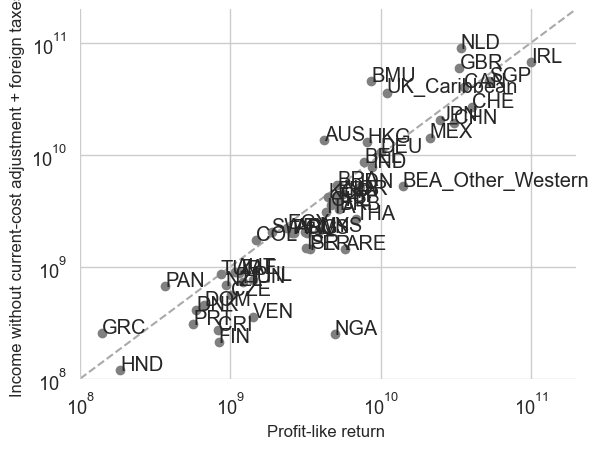

In [55]:
#Compare income without current cost to 

for iso,data in bea.loc[bea["year"]==2018].iterrows():
    iso = data["iso"]

    if (data["pi_without_correction"]<=0) or (data["profit_return"]<=0) or (np.isnan(data["pi_without_correction"])) or (np.isnan(data["profit_return"])):
        continue
    
    plt.scatter(data["profit_return"],data["pi_without_correction"],color="gray")
    plt.annotate(iso,(data["profit_return"],data["pi_without_correction"]))
    
    
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Profit-like return ",fontsize=12)
plt.ylabel("Income without current-cost adjustment + foreign taxes",fontsize=12)
lims = [1E8,2E11]
plt.plot(lims,lims,"--",color="darkgray",zorder=0)
plt.grid()
sns.despine(left=True,bottom=True)
plt.xlim(lims)

plt.ylim(lims)

In [57]:
bea_copy = bea.copy()

In [58]:
bea_income = bea[["iso","year","pi_without_correction","source","type"]].copy()
bea_return = bea[["iso","year","emp","wages","at","t_at","txt","revenue_unrelated","revenue_total","profit_return","net_interest","source","type"]].copy()

bea["pi_capital_gains"] = bea["profit_return"] + bea["capital_gains"].fillna(0)
bea_return_cg = bea[["iso","year","emp","wages","at","t_at","txt","revenue_unrelated","revenue_total","pi_capital_gains","net_interest","source","type"]].copy()

bea_income.columns = ["iso","year","pi","source","type"]
bea_return.columns = ["iso","year","emp","wages","at","t_at","txt","revenue_unrelated","revenue_total","pi","net_interest","source","type"]
bea_return_cg.columns = ["iso","year","emp","wages","at","t_at","txt","revenue_unrelated","revenue_total","pi","net_interest","source","type"]
bea_return["source"] = "BEA_return"
bea_return_cg["source"] = "BEA_return_cg"



In [59]:
#join datas
bea = pd.concat([bea_income,bea_return,bea_return_cg])

In [63]:
# bea = bea.loc[bea["year"]>2009]
bea = bea.loc[bea["year"]<2022]

In [64]:
dev_haven = ["NLD","CHE","SGP","IRL","HKG"]
#island_states = ["PAN","BMU","PRI","CYM","CYP","MLT","ABW","GIB","BHS","IMN","MUS","IRS_Other_Europe","BRB","CUW","IRS_Other_America","VGB","JEY"]
island_states = "CYM, BMU, PRI, JEY, BHS, IMN, BRB, GIB, LUX, UK_Caribbean, BEA_Other_Europe, BEA_Other_Western, VGB, MUS, MLT".split(", ")


In [ ]:
bea["etr"] = bea["txt"]/bea["pi"]
bea.to_csv("data/bea_dataset.tsv",sep="\t",index=None)

In [75]:
x = bea.loc[bea["iso"]=="Rest"]
x.loc[x["source"] == "BEA_return"].tail(5)[["iso","year","pi","txt","etr"]]

,iso,year,pi,txt,etr
2708,Rest,2017,5.388330e+11,1.055660e+11,0.195916
2709,Rest,2018,5.562330e+11,1.181080e+11,0.212335
2710,Rest,2019,5.108470e+11,1.100600e+11,0.215446
2711,Rest,2020,4.393540e+11,9.347900e+10,0.212765
2712,Rest,2021,6.146270e+11,1.315550e+11,0.214040


In [76]:
x = bea.loc[bea["iso"]=="USA"]
x.loc[x["source"] == "BEA_return"].tail(5)[["iso","year","pi","txt","etr"]]

,iso,year,pi,txt,etr
933,USA,2017,9.781910e+11,2.339270e+11,0.239142
1004,USA,2018,1.202740e+12,2.121470e+11,0.176386
1075,USA,2019,1.139434e+12,2.072390e+11,0.181879
1146,USA,2020,8.172560e+11,1.396340e+11,0.170857
1217,USA,2021,1.738953e+12,3.067720e+11,0.176412



## 1.$\Omega$ Combine all

In [92]:
## Combine all of them
df = pd.concat([tax_stats,bea,cbcr_all])


df["etr"] = df["txt"]/df["pi"]
df.to_csv("data/combined_dataset.tsv",sep="\t",index=None)

In [109]:
df.loc[(df["source"]=="CBCR")&(df["iso"]=="USA")&(df["type"]=="all_groups")]

,iso,n_groups,n_firms,revenue_total,revenue_unrelated,at,pi,txt,accum_earnings,source,year,type,emp,wages,t_at,net_interest,revenue_related,txc,capital,dom,etr
3,USA,1017.0,NaN,1.051861e+13,7.799963e+12,NaN,8.678520e+11,1.855401e+11,7.383424e+12,CBCR,2016,all_groups,16377437.0,7.971226e+11,4.223575e+12,NaN,2.718649e+12,1.765794e+11,1.180755e+13,True,0.213792
3,USA,1487.0,NaN,1.392196e+13,1.061798e+13,NaN,1.179986e+12,2.627728e+11,8.357737e+12,CBCR,2017,all_groups,22903463.0,1.114757e+12,5.538479e+12,NaN,3.303975e+12,2.128076e+11,1.476086e+13,True,0.222692
3,USA,1568.0,NaN,1.474207e+13,1.132366e+13,NaN,1.488466e+12,2.231286e+11,8.212735e+12,CBCR,2018,all_groups,23741977.0,1.155570e+12,5.981685e+12,NaN,3.418412e+12,1.406141e+11,1.477828e+13,True,0.149905
3,USA,1627.0,NaN,1.517636e+13,1.167973e+13,NaN,1.295597e+12,1.659446e+11,9.565198e+12,CBCR,2019,all_groups,23958116.0,1.166089e+12,5.871941e+12,NaN,3.496628e+12,2.036940e+11,1.533986e+13,True,0.128084


In [120]:
#Real income share

dev_haven = ["NLD","CHE","SGP","IRL","HKG"]
#island_states = ["PAN","BMU","PRI","CYM","CYP","MLT","ABW","GIB","BHS","IMN","MUS","IRS_Other_Europe","BRB","CUW","IRS_Other_America","VGB","JEY"]
island_states = "CYM, BMU, PRI, JEY, BHS, IMN, BRB, GIB, LUX, UK_Caribbean, BEA_Other_Europe, BEA_Other_Western, VGB, MUS, MLT".split(", ")
real_income["CC"] = real_income["iso"].isin(dev_haven)
real_income["PC"] = real_income["iso"].isin(island_states)
real_income["TH"] = real_income["iso"].isin(island_states+dev_haven)
ri = real_income.loc[real_income["iso"].isin(["Rest","USA"])].groupby("year").sum()[["real_income"]]


th = real_income.loc[real_income["TH"]].groupby("year").sum()[["real_income"]]
cc = real_income.loc[real_income["CC"]].groupby("year").sum()[["real_income"]]
pc = real_income.loc[real_income["PC"]].groupby("year").sum()[["real_income"]]

a = pd.concat([ri,th,cc,pc],axis=1)
a.columns = ["Foreign income","tax haven","coordination centers","profit centers"]
a["share_haven"] = a["tax haven"]/a["Foreign income"]

a.to_excel("/Users/garci061/Dropbox/projects/Gabriel_Javier_Petr/RawData/income_series_2004_2020.xlsx")
a

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3035804277.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ri = real_income.loc[real_income["iso"].isin(["Rest","USA"])].groupby("year").sum()[["real_income"]]
/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3035804277.py:12: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  th = real_income.loc[real_income["TH"]].groupby("year").sum()[["real_income"]]
/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3035804277.py:13: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a fut

,Foreign income,tax haven,coordination centers,profit centers,share_haven
year,,,,,
2004,2.281650e+11,1.040540e+11,7.229400e+10,3.176000e+10,0.456047
2005,2.718770e+11,1.289410e+11,8.717600e+10,4.176500e+10,0.474262
2006,3.041140e+11,1.402560e+11,9.143300e+10,4.882300e+10,0.461195
2007,3.502370e+11,1.747600e+11,1.075180e+11,6.724200e+10,0.498976
2008,3.929540e+11,1.972500e+11,1.211140e+11,7.613600e+10,0.501967
2009,3.400390e+11,1.892990e+11,1.151400e+11,7.415900e+10,0.556698
2010,4.176050e+11,2.254530e+11,1.341330e+11,9.132000e+10,0.539871
2011,4.482350e+11,2.419720e+11,1.540570e+11,8.791500e+10,0.539833
2012,4.380890e+11,2.478560e+11,1.584690e+11,8.938700e+10,0.565766


# Compustat (for aggregated stats)

In [121]:
#Read data (ID and NAICS should be strings)
compustat = pd.read_csv("~/pCloud Drive/Data/Compustat/north_america/ytflcuifwyoxknw7_txt.zip", sep="\t",converters={"gvkey": lambda x: str(x),"naics": lambda x: str(x)})
compustat = compustat.dropna(subset=["gvkey","fyear"])

#Keep US companies
compustat = compustat.loc[compustat["loc"]=="USA"]
#compustat = compustat.loc[compustat["revt"]>850]
print(len(compustat["gvkey"].unique()))

# Faster approach
temp = compustat.groupby(["gvkey","fyear"])["indfmt"].count().reset_index()
temp.columns = ["gvkey","fyear","number"]
compustat = pd.merge(compustat,temp,how="left")

#Keep INDL
compustat = compustat.loc[(compustat["number"]==1)|((compustat["number"]==2)&(compustat["indfmt"]=="INDL"))]

display(compustat.groupby("fyear")["gvkey"].count().tail(30))
#Get companies with international component (remove purely domestic firms, but also some that don't report)

# Faster approach
temp = compustat.groupby(["gvkey"])["pifo"].sum(min_count=1).reset_index()
temp.columns = ["gvkey","pifo_sum"]
compustat = pd.merge(compustat,temp,how="left")

compustat = compustat.loc[np.isfinite(compustat["pifo_sum"])&(compustat["pifo_sum"]!=0)]
print(len(compustat["gvkey"].unique()))
display(compustat.groupby("fyear")["gvkey"].count().tail(10))

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3657493606.py:2: DtypeWarning: Columns (8,10,16,26,30,945,946,948,949,950,955,965,969,970,975) have mixed types. Specify dtype option on import or set low_memory=False.
  compustat = pd.read_csv("~/pCloud Drive/Data/Compustat/north_america/ytflcuifwyoxknw7_txt.zip", sep="\t",converters={"gvkey": lambda x: str(x),"naics": lambda x: str(x)})


31956


fyear
1992     9339
1993     9934
1994    10171
1995    10592
1996    10659
1997    10409
1998    10337
1999    10171
2000     9691
2001     9211
2002     8835
2003     8587
2004     8319
2005     8119
2006     8002
2007     7954
2008     7742
2009     7667
2010     7725
2011     8075
2012     8186
2013     8215
2014     8076
2015     8000
2016     7885
2017     7796
2018     7859
2019     7798
2020     7678
2021      564
Name: gvkey, dtype: int64

5670


fyear
2012    2473
2013    2459
2014    2404
2015    2322
2016    2246
2017    2164
2018    2132
2019    2070
2020    1973
2021     200
Name: gvkey, dtype: int64

In [122]:
#Both zero or profits != 0 and txfo not missing
compustat["info_foreign"] = (np.isfinite(compustat["pifo"])&(compustat["pifo"]!=0)&np.isfinite(compustat["txfo"]))|((compustat["pifo"]==0)&(compustat["txfo"]==0))
compustat["n"] = 1
compustat["pi_winsor"] = winsorize(compustat["pi"],[0.01,0.01])

c = compustat.groupby(["fyear","info_foreign"]).sum()[["pi","pifo"]].reset_index()
c = pd.pivot_table(c, values=["pi","pifo"],index="fyear",columns="info_foreign")

c.columns = ["No_info","Info","_","pifo"]
c *= 1E6
c["Share of profits made by companies with info on foreign profits"] = c["Info"]/(c["Info"]+c["No_info"])
c.to_csv("./data/compustat_profits.csv")

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3072668435.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  c = compustat.groupby(["fyear","info_foreign"]).sum()[["pi","pifo"]].reset_index()


In [ ]:
comp_sample_for = compustat.loc[compustat["info_foreign"]].copy()
comp_sample_for["txdom"] = comp_sample_for["txc"] - comp_sample_for["txfo"]
comp_sample_for["txdom_paid"] = comp_sample_for["txt"]-comp_sample_for["txfo"] #very similar to the sum of txfed and txs


comp_sample_for["pi_winsor"] = winsorize(comp_sample_for["pi"],[0.01,0])
comp_sample_for["pifo_winsor"] = comp_sample_for["pifo"]*comp_sample_for["pi_winsor"]/comp_sample_for["pi"] 
comp_sample_for["txc_winsor"] = comp_sample_for["txc"]*comp_sample_for["pi_winsor"]/comp_sample_for["pi"] 
comp_sample_for["txt_winsor"] = comp_sample_for["txt"]*comp_sample_for["pi_winsor"]/comp_sample_for["pi"] 
comp_sample_for["txfo_winsor"] = comp_sample_for["txfo"]*comp_sample_for["pi_winsor"]/comp_sample_for["pi"] 
comp_sample_for["pidom_winsor"] = comp_sample_for["pidom"]*comp_sample_for["pi_winsor"]/comp_sample_for["pi"] 
comp_sample_for["txdom_winsor"] = comp_sample_for["txdom"]*comp_sample_for["pi_winsor"]/comp_sample_for["pi"] 
comp_sample_for["txdom_paid_winsor"] = comp_sample_for["txdom_paid"]*comp_sample_for["pi_winsor"]/comp_sample_for["pi"] 


comp_all = comp_sample_for.groupby("fyear").sum()[["txt","txc","txfo","txdom","pi","pifo","pidom","n","pi_winsor","pifo_winsor","pidom_winsor","txfo_winsor","txdom_winsor","txdom_paid_winsor","txc_winsor","txt_winsor","txdom_paid"]]
comp_pos = comp_sample_for.loc[comp_sample_for["pi"]>0].groupby("fyear").sum()[["txt","txc","txfo","txdom","pi","pifo","pidom","n","txdom_paid"]]

comp_all["etr_c"] = comp_all["txc"]/comp_all["pi"]
comp_all["etr_t"] = comp_all["txt"]/comp_all["pi"]
comp_all["etr_fo_c"] = comp_all["txfo"]/comp_all["pifo"]
comp_all["etr_winsor_c"] = comp_all["txc_winsor"]/comp_all["pi_winsor"]
comp_all["etr_winsor_t"] = comp_all["txt_winsor"]/comp_all["pi_winsor"]
comp_all["etr_fo_winsor_c"] = comp_all["txfo_winsor"]/comp_all["pifo_winsor"]
comp_all["etr_dom_winsor_c"] = comp_all["txdom_winsor"]/comp_all["pidom_winsor"]
comp_all["etr_dom_winsor_t"] = comp_all["txdom_paid_winsor"]/comp_all["pidom_winsor"]

comp_all["etr_dom_c"] = comp_all["txdom"]/comp_all["pidom"]
comp_all["etr_dom_t"] = comp_all["txdom_paid"]/comp_all["pidom"]

comp_pos["etr_c"] = comp_pos["txc"]/comp_pos["pi"]
comp_pos["etr_fo_c"] = comp_pos["txfo"]/comp_pos["pifo"]
comp_pos["etr_dom_c"] = comp_pos["txdom"]/comp_pos["pidom"]
comp_pos["etr_t"] = comp_pos["txt"]/comp_pos["pi"]
comp_pos["etr_dom_t"] = comp_pos["txdom_paid"]/comp_pos["pidom"]

comp_save = pd.merge(comp_all,comp_pos,suffixes=["_all","_pos"],on="fyear")
comp_save[["etr_c_all","etr_c_pos","etr_t_all","etr_t_pos","etr_fo_c_all","etr_fo_c_pos"]].tail(7)
comp_save["share_pi_fo_all"] = comp_save["pifo_all"]/comp_save["pi_all"]
comp_save["share_pi_fo_winsor_all"] = comp_save["pifo_winsor"]/comp_save["pi_winsor"]
comp_save["share_pi_fo_pos"] = comp_save["pifo_pos"]/comp_save["pi_pos"]


comp_save = pd.merge(comp_save,c[["Share of profits made by companies with info on foreign profits"]], on="fyear" )

comp_save = comp_save.reset_index().rename(columns={"fyear":"year"})
comp_save.to_excel("data/compustat_all_etrs.xlsx")

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/2324179241.py:16: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  comp_all = comp_sample_for.groupby("fyear").sum()[["txt","txc","txfo","txdom","pi","pifo","pidom","n","pi_winsor","pifo_winsor","pidom_winsor","txfo_winsor","txdom_winsor","txdom_paid_winsor","txc_winsor","txt_winsor","txdom_paid"]]
/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/2324179241.py:17: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  comp_pos = comp_sample_for.loc[comp_sample_for["pi"]>0].groupby("fyear").sum()[["txt","txc","txfo","txdom","pi","pifo","pidom

In [125]:
comp_save[["etr_c_all","etr_c_pos","etr_t_all","etr_t_pos","etr_fo_c_all","etr_fo_c_pos","etr_fo_winsor_c","share_pi_fo_all","share_pi_fo_pos","share_pi_fo_winsor_all"]].tail(27)


,etr_c_all,etr_c_pos,etr_t_all,etr_t_pos,etr_fo_c_all,etr_fo_c_pos,etr_fo_winsor_c,share_pi_fo_all,share_pi_fo_pos,share_pi_fo_winsor_all
15,0.311890,0.286708,0.363019,0.347049,0.337296,0.321603,0.334704,0.365842,0.345270,0.364496
16,0.301262,0.286353,0.357951,0.348123,0.361220,0.351648,0.360960,0.350157,0.334191,0.349157
17,0.314063,0.291657,0.360945,0.345217,0.362458,0.349843,0.361841,0.347408,0.331351,0.345648
18,0.323383,0.280586,0.349071,0.325425,0.385037,0.351599,0.382967,0.321130,0.291140,0.313576
19,0.284300,0.269300,0.365483,0.351601,0.330872,0.314701,0.330864,0.328827,0.317938,0.328501
20,0.313941,0.278161,0.385712,0.349871,0.339920,0.316280,0.334788,0.367931,0.343884,0.361588
21,0.667846,0.269143,0.673710,0.343324,0.378229,0.314672,0.352570,0.838261,0.385618,0.471255
22,0.351666,0.211642,0.515162,0.309587,0.331527,0.279886,0.311418,0.595247,0.380091,0.440469
23,0.241360,0.213875,0.322209,0.288798,0.274584,0.262577,0.273736,0.394312,0.354135,0.386997
24,0.280637,0.250529,0.318624,0.294628,0.285504,0.281574,0.284277,0.481618,0.430780,0.459749


In [126]:
#Compustat by sector
compustat.groupby("naics").count()

,gvkey,datadate,fyear,indfmt,consol,popsrc,datafmt,tic,cusip,conm,acctchg,acctstd,acqmeth,adrr,ajex,ajp,bspr,compst,curcd,curncd,currtr,curuscn,final,fyr,ismod,ltcm,ogm,pddur,scf,src,stalt,udpl,upd,apdedate,fdate,pdate,acchg,acco,accrt,acdo,aco,acodo,acominc,acox,acoxar,acqao,acqcshi,acqgdwl,acqic,acqintan,...,dvpsx_f,mkvalt,prcc_f,prch_f,prcl_f,adjex_f,rank,au,auop,auopic,ceoso,cfoso,add1,add2,add3,add4,addzip,busdesc,city,conml,county,dlrsn,ein,fax,fyrc,ggroup,gind,gsector,gsubind,idbflag,incorp,loc,phone,prican,prirow,priusa,sic,spcindcd,spcseccd,spcsrc,state,stko,weburl,dldte,ipodate,number,pifo_sum,info_foreign,n,pi_winsor
naics,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,101,101,101,101,101,101,101,101,101,101,0,92,5,0,101,101,6,21,101,101,101,0,101,101,92,0,0,101,87,101,0,0,101,0,0,0,0,0,0,0,92,0,0,92,0,0,0,0,0,0,...,87,0,83,83,83,87,72,72,72,0,0,0,101,0,0,0,101,53,101,101,18,101,101,38,101,0,0,0,0,101,15,101,71,0,0,101,101,101,101,0,101,101,0,101,0,101,101,101,101,92
111,33,33,33,33,33,33,33,33,33,33,3,27,8,0,33,33,0,13,33,33,33,0,33,33,27,10,0,33,27,33,0,0,33,19,18,15,24,0,6,20,27,20,21,27,0,2,2,4,0,4,...,23,20,23,23,23,23,27,27,27,17,19,19,33,0,0,0,33,26,33,33,7,27,33,0,33,33,33,33,33,33,33,33,33,0,0,33,33,27,27,20,33,33,6,27,27,33,33,33,33,27
111150,38,38,38,38,38,38,38,38,38,38,0,38,7,0,38,38,0,10,38,38,38,0,38,38,38,0,0,38,38,38,0,0,38,0,0,0,22,0,0,0,38,0,0,38,0,0,0,0,0,0,...,38,2,35,35,35,38,37,37,37,0,0,0,38,0,0,0,38,38,38,38,0,38,38,38,38,38,38,38,38,38,38,38,38,0,0,38,38,38,38,0,38,38,26,38,12,38,38,38,38,38
111320,13,13,13,13,13,13,13,13,13,13,3,13,3,0,13,13,0,4,13,13,13,0,13,13,13,10,0,13,13,13,0,0,13,13,13,4,13,0,0,13,13,13,13,13,0,1,4,3,3,4,...,13,13,13,13,13,13,13,13,13,13,13,13,13,0,0,0,13,13,13,13,0,0,13,0,13,13,13,13,13,13,13,13,13,0,0,13,13,0,0,13,13,13,13,0,0,13,13,13,13,13
111339,88,88,88,88,88,88,88,88,88,88,3,88,15,0,88,88,0,43,88,88,88,0,88,88,88,5,0,88,83,88,1,0,88,21,15,3,50,0,0,25,88,25,25,88,0,1,0,1,0,2,...,88,25,83,83,83,88,79,79,79,19,21,21,88,0,0,0,88,88,88,88,0,88,88,0,88,88,88,88,88,88,88,88,88,0,0,88,88,88,88,44,88,88,88,88,0,88,88,88,88,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812331,111,111,111,111,111,111,111,111,111,111,4,111,23,0,111,111,0,45,111,111,111,0,111,111,111,10,0,111,108,110,0,0,111,23,18,17,68,0,0,28,111,28,28,111,0,1,6,8,1,8,...,111,38,110,110,110,111,102,102,102,21,23,23,111,0,0,0,111,111,111,111,0,72,111,72,111,111,111,111,111,111,111,111,111,0,0,111,111,111,111,78,111,111,78,72,0,111,111,111,111,111
812930,33,33,33,33,33,33,33,33,33,33,4,33,4,0,33,33,0,8,33,33,33,0,33,33,33,10,0,33,33,33,0,0,33,22,16,14,32,0,0,25,33,25,26,33,0,1,1,1,0,1,...,30,26,28,28,28,30,33,33,33,19,22,22,33,0,0,0,33,33,33,33,0,13,33,13,33,33,33,33,33,33,33,33,33,0,0,33,33,13,13,33,33,33,20,13,33,33,33,33,33,33
812990,53,53,53,53,53,53,53,53,53,53,2,51,10,0,53,53,0,15,53,53,53,0,53,53,51,3,0,53,51,53,0,0,53,16,12,3,47,0,0,21,51,21,22,51,0,0,0,0,0,0,...,53,27,50,50,50,53,51,50,50,13,16,16,53,0,0,0,53,53,53,53,0,31,53,53,53,53,53,53,53,53,53,53,53,0,0,53,53,53,53,42,53,53,11,31,42,53,53,53,53,51


In [ ]:
compustat_find_top = compustat.copy()
compustat_find_top["txdom_acc"] = compustat_find_top["txt"]-compustat_find_top["txfo"] #very similar to the sum of txfed and txs
compustat_find_top["year"] = compustat_find_top["fyear"].map({2015: "pre", 2016: "pre", 2018: "post", 2019: "post"})
compustat_find_top["naics"] = compustat_find_top["naics"].fillna("na")
compustat_find_top = compustat_find_top.groupby(["conm","naics","year"]).sum()
profits_vars = ["pi","pidom","pifo","txt","txdom_acc","txfo"]

delta_tcja = compustat_find_top.groupby("year").sum()[profits_vars]
print(profits_vars)
print(-delta_tcja.diff().loc["pre"].values/1E3)
print((-delta_tcja.diff().loc["pre"]/delta_tcja.loc["pre"]).values)

d = -delta_tcja.diff().loc["pre"].values/1E3

compustat_find_top = compustat_find_top.reset_index()
compustat_find_top["naics"] = compustat_find_top["naics"].str[:2]


for i,var in enumerate(profits_vars):
    c_one_var = pd.pivot_table(compustat_find_top, index = ["conm","naics"], columns = "year", values = var)
    c_one_var["diff"] = c_one_var["post"]-c_one_var["pre"]
    c_one_var = c_one_var.sort_values(by="diff")
    #Top 5
    print(var)
    top5 = c_one_var[["pre","post","diff"]].head(20)/1E3
    print(f"Top 10 companies contributing to decrease in {var}: {top5['diff'].sum():2.1f}B ({np.abs(top5['diff'].sum()/d[i]):2.1%} of total)")
    display(top5.round(1))
    
    c_one_var = c_one_var.sort_values(by="diff",ascending=False)
    bottom5 = c_one_var[["pre","post","diff"]].head(20)/1E3
    print(f"Top 10 companies contributing to increase in {var}: {bottom5['diff'].sum():2.1f}B ({np.abs(bottom5['diff'].sum()/d[i]):2.1%} of total)")
    display(bottom5.round(1))
    

sec_inf = []
for i,var in enumerate(profits_vars):
    c_one_var = pd.pivot_table(compustat_find_top, index = ["naics"], columns = "year", values = var, aggfunc="sum")
    c_one_var["diff"] = c_one_var["post"]-c_one_var["pre"]
    c_one_var = c_one_var.sort_values(by="diff")
    #Top 5
    print(var)
    top5 = (c_one_var[["pre","post","diff"]].head(10)/1E3).round(1)
    print(f"Top 3 sectors contributing to decrease in {var}: {top5['diff'].sum():2.1f}B ({np.abs(top5['diff'].sum()/d[i]):2.1%} of total)")
    display(top5.round(1))
    
    c_one_var = c_one_var.sort_values(by="diff",ascending=False)
    bottom5 = (c_one_var[["pre","post","diff"]].head(10)/1E3).round(1)
    print(f"Top 3 sectors contributing to increase in {var}: {bottom5['diff'].sum():2.1f}B ({np.abs(bottom5['diff'].sum()/d[i]):2.1%} of total)")
    display(bottom5.round(1))    
    
    top5 = top5.reset_index()
    top5["Contribution"] = "Decrease"
    bottom5= bottom5.reset_index()
    bottom5["Contribution"] = "Increase"
    
    top_and_bottom = pd.concat([top5,bottom5]).set_index(["Contribution"])
    top_and_bottom.columns = pd.MultiIndex.from_tuples([(var, _) for _ in top_and_bottom.columns])
    sec_inf.append(top_and_bottom)


['pi', 'pidom', 'pifo', 'txt', 'txdom_acc', 'txfo']
[ 462.677402  173.124189  293.124856  -68.362587 -132.420925   66.161931]
[ 0.24524123  0.18952815  0.33181207 -0.13043994 -0.41638672  0.32737131]
pi
Top 10 companies contributing to decrease in pi: -218.7B (47.3% of total)


/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/1024273226.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  compustat_find_top = compustat_find_top.groupby(["conm","naics","year"]).sum()


,year,pre,post,diff
conm,naics,,,
GENERAL ELECTRIC CO,99,17.2,-19.0,-36.2
GILEAD SCIENCES INC,32,38.8,13.0,-25.8
ALTRIA GROUP INC,31,29.9,10.1,-19.8
KRAFT HEINZ CO,31,6.0,-8.7,-14.7
FORD MOTOR CO,33,17.0,3.7,-13.3
WALMART INC,45,42.1,31.6,-10.6
NEWELL BRANDS INC,33,1.2,-9.1,-10.3
TWENTY-FIRST CENTURY FOX INC,51,14.0,4.4,-9.6
DUPONT DE NEMOURS INC,32,14.3,5.0,-9.3


Top 10 companies contributing to increase in pi: 420.4B (90.9% of total)


,year,pre,post,diff
conm,naics,,,
MICROSOFT CORP,51,38.3,80.2,41.9
CONOCOPHILLIPS,21,-12.8,19.5,32.3
META PLATFORMS INC,51,18.7,50.2,31.5
ALPHABET INC,51,43.8,74.5,30.7
APA CORP,21,-29.9,-2.0,27.9
DEVON ENERGY CORP,21,-25.1,0.8,26.0
CHEVRON CORP,32,2.7,26.1,23.4
FREEPORT-MCMORAN INC,21,-17.5,4.2,21.7
EXXON MOBIL CORP,32,29.9,51.0,21.1


...

year,pre,post,diff
naics,,,
21,-47.1,-1.9,45.2
23,1.1,1.5,0.4
61,-0.1,0.2,0.3
71,0.4,0.4,0.0
48,3.1,2.9,-0.2
81,0.8,0.4,-0.4
22,-0.4,-0.8,-0.5
53,3.2,2.1,-1.1
62,5.5,4.0,-1.5


txfo
Top 3 sectors contributing to decrease in txfo: -2.2B (3.3% of total)


year,pre,post,diff
naics,,,
99,6.8,4.0,-2.9
62,0.3,0.3,-0.1
22,1.0,1.0,-0.0
61,0.3,0.3,-0.0
23,0.4,0.4,-0.0
81,0.1,0.1,0.0
71,0.1,0.2,0.1
11,0.6,0.8,0.1
49,0.9,1.2,0.3


Top 3 sectors contributing to increase in txfo: 66.2B (100.1% of total)


year,pre,post,diff
naics,,,
32,50.5,67.8,17.3
51,22.3,38.4,16.0
33,51.7,63.2,11.6
21,10.1,21.1,11.0
52,24.2,29.9,5.7
54,3.9,5.2,1.3
72,4.3,5.2,0.9
56,1.9,2.8,0.8
31,10.8,11.6,0.8


In [128]:
pd.concat(sec_inf, axis=1)

pi                      pidom                       pifo  \
             naics    pre   post   diff naics    pre   post   diff naics   
Contribution                                                               
Decrease        31  169.1  112.3  -56.9    31   99.9   47.5  -52.5    99   
Decrease        99   13.4  -20.2  -33.6    11    3.6   -5.9   -9.4    45   
Decrease        11    5.2   -5.1  -10.3    99   -2.0  -11.0   -9.0    31   
Decrease        44   78.0   70.2   -7.8    49   16.2    9.0   -7.1    54   
Decrease        42   42.5   35.8   -6.7    48    7.5    1.0   -6.6    11   
Decrease        48   16.0    9.7   -6.4    42   31.6   25.6   -6.1    42   
Decrease        49   19.8   14.0   -5.8    56   16.5   11.3   -5.2    23   
Decrease        54   24.6   19.8   -4.8    54   11.0    6.2   -4.8    44   
Decrease        56   23.6   19.0   -4.6    32   99.7   96.5   -3.2    61   
Decrease        23    3.6    3.4   -0.3    44   61.7   58.6   -3.1    62   
Increase        21 -206.5   47.2  253.7    21 -152.3    1.1  153.3    51   
Increase        33  486.8  594.2  107.4    52  188.1  225.2   37.1    33   
Increase        51  378.2  485.5  107.2    51  217.4  254.4   37.0    21   
Increase        52  308.6  378.8   70.2    33  198.5  217.7   19.2    32   
Increase        32  358.7  387.2   28.5    45   55.6   71.2   15.6    52   
Increase        53   23.7   35.1   11.4    53   17.5   25.3    7.8    72   
Increase        72   44.3   53.7    9.5    22    0.3    3.5    3.2    53   
Increase        45   69.7   75.2    5.5    72   23.9   26.7    2.8    48   
Increase        22    5.3    8.1    2.8    62   14.0   16.0    2.0    49   
Increase        62   17.6   19.0    1.4    81    2.1    3.1    1.1    56   

                                   txt                    txdom_acc        \
                pre   post  diff naics    pre  post  diff     naics   pre   
Contribution                                                                
Decrease       15.5   -9.2 -24.7    31   47.8  17.0 -30.8        33  68.6   
Decrease       12.4    4.3  -8.1    33  121.1  94.8 -26.2        31  37.1   
Decrease       63.9   58.3  -5.6    52   87.1  71.4 -15.7        51  81.2   
Decrease       14.0   12.3  -1.8    51  103.5  88.6 -14.8        52  62.3   
Decrease        1.6    0.7  -0.9    44   26.6  17.0  -9.6        32  26.4   
Decrease       10.1    9.3  -0.8    54    8.4   2.7  -5.7        44  24.3   
Decrease        1.3    0.7  -0.6    45   23.3  17.8  -5.5        54   4.3   
Decrease       11.0   10.5  -0.5    42   12.7   7.4  -5.4        45  18.2   
Decrease        1.3    0.8  -0.5    99    6.2   1.4  -4.8        42  10.1   
Decrease        0.8    0.4  -0.4    49    6.7   2.9  -3.8        49   5.8   
Increase      129.8  221.8  92.0    21  -37.0  19.3  56.3        21 -47.1   
Increase      281.4  371.5  90.0    48    2.2   5.6   3.4        23   1.1   
Increase      -28.3   43.5  71.8    32   80.1  81.9   1.9        61  -0.1   
Increase      240.1  275.2  35.1    23    1.5   1.9   0.4        71   0.4   
Increase       88.1  120.4  32.3    61    0.2   0.5   0.3        48   3.1   
Increase       19.1   27.0   7.9    71    0.6   0.7   0.1        81   0.8   
Increase        5.5    8.7   3.1    81    0.9   0.5  -0.3        22  -0.4   
Increase        0.4    2.1   1.7    53    4.8   4.3  -0.4        53   3.2   
Increase        3.6    5.0   1.3    22    0.6   0.1  -0.5        62   5.5   
Increase        6.6    7.7   1.1    11    1.6   0.2  -1.4        11   0.9   

                          txfo                    
              post  diff naics   pre  post  diff  
Contribution                                      
Decrease      33.6 -35.0    99   6.8   4.0  -2.9  
Decrease       5.5 -31.6    62   0.3   0.3  -0.1  
Decrease      50.3 -30.9    22   1.0   1.0  -0.0  
Decrease      41.2 -21.2    61   0.3   0.3  -0.0  
Decrease      12.8 -13.5    23   0.4   0.4  -0.0  
Decrease      14.4  -9.9    81   0.1   0.1   0.0  
Decrease      -2.7  -7.0    71   0.1

In [129]:
delta_tcja

,pi,pidom,pifo,txt,txdom_acc,txfo
year,,,,,,
post,2349298.996,1086572.600,1176531.096,455729.842,185602.968,268262.506
pre,1886621.594,913448.411,883406.240,524092.429,318023.893,202100.575


In [130]:
compustat_find_top.groupby("year").sum()[profits_vars].diff()

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/1810757806.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  compustat_find_top.groupby("year").sum()[profits_vars].diff()


,pi,pidom,pifo,txt,txdom_acc,txfo
year,,,,,,
post,NaN,NaN,NaN,NaN,NaN,NaN
pre,-462677.402,-173124.189,-293124.856,68362.587,132420.925,-66161.931


In [131]:
#Plto by sector
comp_sector = comp_sample_for.copy()
comp_sector = comp_sector.loc[(comp_sector["pi"]>0)]#&(comp_sector["pifo"]>0)&(comp_sector["pidom"]>0)]
comp_sector["naics"] = comp_sector["naics"].str[:2]

comp_sector = comp_sector.loc[(comp_sector["fyear"]<2021)&(comp_sector["fyear"]>1983)]

top_sectors = comp_sector.groupby("naics").sum()["pi_winsor"].sort_values(ascending=False)
print(top_sectors.sum()/1E6)
print(top_sectors.head(10)/top_sectors.sum())

print("Top 6", top_sectors.head(5).sum()/top_sectors.sum())


top_sectors = top_sectors.head(5).index

22.325472448
naics
33    0.238071
32    0.212555
51    0.148923
52    0.116382
31    0.073318
21    0.048910
45    0.029033
44    0.023826
99    0.020128
72    0.014912
Name: pi_winsor, dtype: float64
Top 6 0.7892492791828242


/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3397555544.py:8: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  top_sectors = comp_sector.groupby("naics").sum()["pi_winsor"].sort_values(ascending=False)


In [5]:

naics2text = {"31": "31: Manufacture: Food and textiles",
              "32": "32: Manufacture: Pharma, petroleum, chemicals",
              "33": "33: Manufacture: Metals, machinery and electronics",
              "51": "51: Information",
              "52": "52: Finance and Insurance",
              "21": "21: Mining and oil extraction",
             "99":"Un"}

palette = [(64, 83, 211), (221, 179, 16), (181, 29, 20), (0, 190, 255), (251, 73, 176), (0, 178, 93), (202, 202, 202)]
palette = list(np.array(palette)/255)

palette = sns.color_palette("Reds_r",3) + palette[3:4]+ palette[5:6] +["k"]



/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/987080791.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  comp_analyze = comp_analyze.groupby("fyear").sum()
/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/987080791.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  comp_analyze = comp_analyze.groupby("fyear").sum()
/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/987080791.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or sel

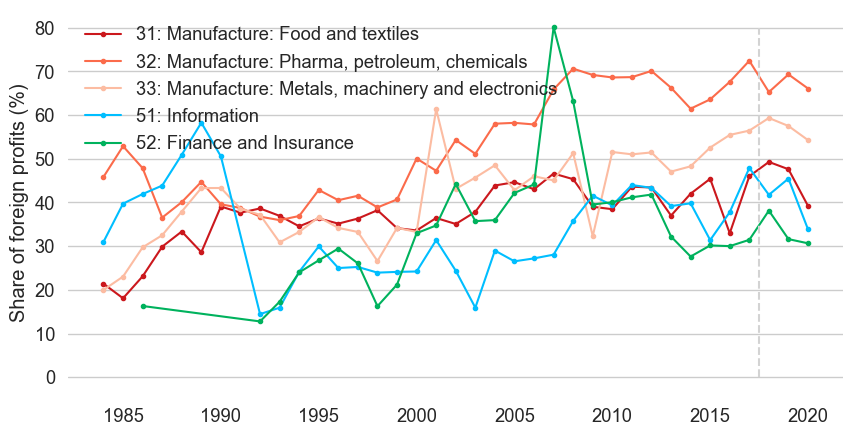

In [ ]:
plt.figure(figsize=(10,5))


for sec in sorted(top_sectors):
    comp_analyze = comp_sector.loc[comp_sector["naics"]==sec]
    comp_analyze = comp_analyze.groupby("fyear").sum()
    
    comp_analyze["share_fo"] =  comp_analyze["pifo"]/comp_analyze["pi"]
    comp_analyze.loc[comp_analyze["pi"]<10E3, "share_fo"] = np.nan
    
    comp_analyze = comp_analyze.reset_index().dropna(subset=["share_fo"])
#     sns.regplot("fyear","share_fo",lowess=True,data=comp_analyze)
    plt.plot(comp_analyze["fyear"], 100*comp_analyze["share_fo"],".-", label=naics2text.get(sec),
            color = palette.pop(0))
    
plt.ylabel("Share of foreign profits (%)")
plt.gca().grid(axis='y')
plt.legend(frameon=False)
sns.despine(bottom=True,left=True)
plt.plot([2017.5,2017.5],[0,80],"--",color="lightgray")
plt.savefig("./results/figures/compustat_share_foreign_by_sector.pdf",bbox_inches="tight")

In [134]:

comp_sector["year"] = comp_sector["fyear"].map({2015: "pre", 2016: "pre", 2019: "post", 2020: "post"})

comp_sector2 = comp_sector.groupby(["conm","naics","year"]).sum()
comp_sector2["share_fo"] = comp_sector2["pifo"]/comp_sector2["pi"]
comp_sector2 = comp_sector2.loc[comp_sector2["pi"]>5E3]

comp_sector2 = pd.pivot_table(comp_sector2, values=["pidom","pi","pifo","share_fo"],index=["conm","naics"],columns="year")
comp_sector2["diff"] = 100*(comp_sector2[("share_fo","pre")] - comp_sector2[("share_fo","post")])
comp_sector2["diff_weighted"] = 100*comp_sector2[("pi","pre")]/comp_sector2[("pi","pre")].sum()*comp_sector2["diff"] 
comp_sector2["increased_dom"] = comp_sector2[("pidom","post")] - comp_sector2[("pidom","pre")]
comp_sector2["decrease_fo"] = comp_sector2[("pifo","pre")] - comp_sector2[("pifo","post")]
#comp_sector2["flag1"] = comp_sector2.loc[comp_sector2["increased_dom"]>0]

comp_sector2=  comp_sector2.sort_values(by="diff_weighted",ascending=False)#.reset_index()
comp_sector2 = comp_sector2[["diff","diff_weighted","increased_dom","decrease_fo"]]
comp_sector2 = comp_sector2.loc[(comp_sector2["increased_dom"]>1E3)&((comp_sector2["decrease_fo"]>0))]
comp_sector2.head(30).round(1)
# comp_sector2.loc[comp_sector2["naics"]=="31"]

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/3057734911.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  comp_sector2 = comp_sector.groupby(["conm","naics","year"]).sum()


,,diff,diff_weighted,increased_dom,decrease_fo
,year,,,,
conm,naics,,,,
PFIZER INC,32,110.2,132.6,20786.0,12924.0
NIKE INC -CL B,31,67.8,44.8,6481.0,6442.0
CISCO SYSTEMS INC,33,26.2,43.9,8668.0,4248.0
QUALCOMM INC,33,46.0,42.6,6021.0,6141.0
WALMART INC,45,14.4,42.1,4736.0,6191.0
APPLE INC,33,4.2,39.2,5241.0,6300.0
EXXON MOBIL CORP,32,18.7,38.9,5632.0,15511.0
COCA-COLA CO,31,20.4,25.1,4484.0,1690.0


### Compustat distribution of changes

In [ ]:
comp_dist = compustat.copy()
comp_dist["txdom_acc"] = comp_dist["txt"]-comp_dist["txfo"] #very similar to the sum of txfed and txs
comp_dist["year"] = comp_dist["fyear"].map({2012:"1comp",2013:"1comp",2015: "2pre", 2016: "2pre", 2018: "3post", 2019: "3post", 2020: "3post"})
comp_dist["naics"] = comp_dist["naics"].fillna("na")
comp_dist = comp_dist.groupby(["conm","naics","year"]).sum()

comp_dist["share_fo"] = comp_dist["pifo"]/comp_dist["pi"]
# comp_dist["share_fo"] = comp_dist["dlc"]/comp_dist["at"]


profits_vars = ["pi","pidom","pifo","txt","txdom_acc","txfo","share_fo"]

comp_dist = pd.pivot_table(index=["conm","naics"],columns="year",values=["pi","pidom","at","pifo","share_fo"], data=comp_dist).reset_index()
comp_dist["naics"] = comp_dist["naics"].str[:2]


#Filter companeis with no profits
filter_ = (comp_dist[[("pi","1comp"),("pi","2pre"),("pi","3post")]]>0).sum(1)==3
print(len(comp_dist))
comp_dist = comp_dist.loc[filter_]
print(len(comp_dist))

comp_dist["diff_1"] = comp_dist[("share_fo","2pre")] -comp_dist[("share_fo","1comp")]
comp_dist["diff_2"] = comp_dist[("share_fo","3post")] -comp_dist[("share_fo","2pre")]

filter_ = (comp_dist["diff_1"].abs()<0.5) & (comp_dist["diff_2"].abs()<0.5)
comp_dist = comp_dist.loc[filter_]
print(len(comp_dist))

comp_dist.head()

2937
839
644


/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/796529460.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  comp_dist = comp_dist.groupby(["conm","naics","year"]).sum()


conm naics          at                          \
year                                         1comp        2pre       3post   
4                          3M CO    32   67426.000   65624.000  128503.000   
10    A-MARK PRECIOUS METALS INC    42     618.723     763.049    2206.398   
12                      AAR CORP    42    4336.400    2946.200    5135.900   
14           ABBOTT LABORATORIES    33  110187.944   93913.000  207608.000   
15                    ABBVIE INC    32   56206.000  119149.000  299032.000   

             pi                         pidom                         pifo  \
year      1comp       2pre      3post   1comp      2pre     3post    1comp   
4     12913.000  13876.000  19418.000  6096.0  8765.000  10215.00   6817.0   
10       39.482     24.712     37.744     0.0    24.405     37.66      0.0   
12      187.500    133.600    183.900     0.0   101.000    136.20      0.0   
14     8808.614   4633.000  11918.000   -91.0  1095.000   2047.00   8875.0   
15    11057.000  14529.000  17021.000    44.0 -2689.000 -11525.00  11013.0   

                            share_fo                        diff_1    diff_2  
year       2pre      3post     1comp      2pre     3post                      
4      5111.000   9208.000  0.527918  0.368334  0.474199 -0.159584  0.105865  
10        0.307      0.084  0.000000  0.012423  0.002226  0.012423 -0.010198  
12       32.600     47.700  0.000000  0.244012  0.259380  0.244012  0.015368  
14     3501.000   9871.000  1.007536  0.755666  0.828243 -0.251871  0.072577  
15    17218.000  28546.000  0.996021  1.185078  1.677105  0.189057  0.492027

In [136]:
from adjustText import adjust_text

{'31': (0.7971856978085351, 0.09519415609381007, 0.11418685121107267), '32': (0.9843752402921953, 0.4181468665897732, 0.2926566705113418), '33': (0.9884198385236448, 0.7367474048442906, 0.6358938869665514), '51': array([0.        , 0.74509804, 1.        ]), '52': array([0.        , 0.69803922, 0.36470588]), '21': 'k'}


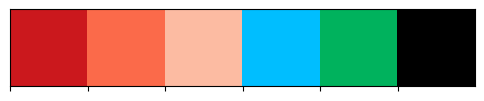

In [7]:
palette = [(64, 83, 211), (221, 179, 16), (181, 29, 20), (0, 190, 255), (251, 73, 176), (0, 178, 93), (202, 202, 202)]
palette = list(np.array(palette)/255)

palette = sns.color_palette("Reds_r",3) + palette[3:4]+ palette[5:6] +["k"]

naics2color = dict(zip(naics2text.keys(),palette))
print(naics2color)
sns.palplot(palette)
comp_dist["color"] = comp_dist["naics"].map(naics2color).fillna("gray")


In [8]:
naics2text

{'31': '31: Manufacture: Food and textiles',
 '32': '32: Manufacture: Pharma, petroleum, chemicals',
 '33': '33: Manufacture: Metals, machinery and electronics',
 '51': '51: Information',
 '52': '52: Finance and Insurance',
 '21': '21: Mining and oil extraction',
 '99': 'Un'}

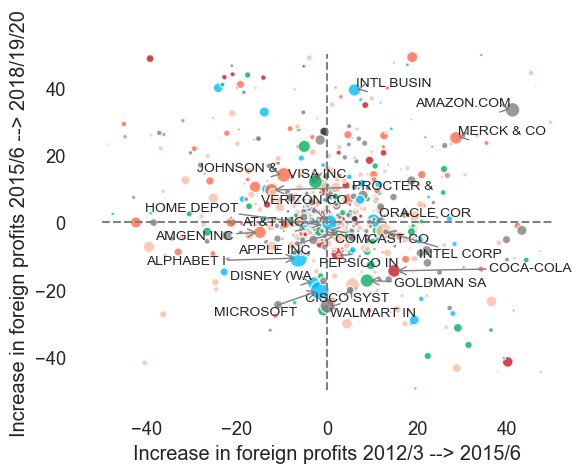

In [141]:
texts = []

plt.scatter(comp_dist["diff_1"]*100,comp_dist["diff_2"]*100,s=0.5*np.sqrt(comp_dist[("pi","3post")]),edgecolor="white",
            alpha=0.8,color=comp_dist["color"])

for c,row in comp_dist.iterrows():
    if row[("pi","3post")] > 2.5E4:
        texts.append(plt.text(row["diff_1"].values[0]*100,row["diff_2"].values[0]*100,row["conm"].values[0][:10], fontsize=10))
        
plt.plot([-50,50],[0,0],"--",color="gray")
plt.plot([0,0],[-50,50],"--",color="gray")

plt.xlabel("Increase in foreign profits 2012/3 --> 2015/6")
plt.ylabel("Increase in foreign profits 2015/6 --> 2018/19/20")

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
sns.despine(left=True,bottom=True)
plt.savefig("/Users/garci061/Downloads/sectors_increased.pdf", bbox_inches="tight")

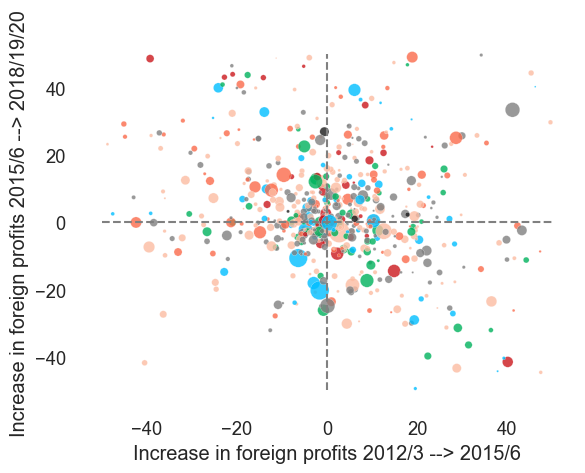

In [142]:
texts = []

plt.scatter(comp_dist["diff_1"]*100,comp_dist["diff_2"]*100,s=0.5*np.sqrt(comp_dist[("pi","3post")]),edgecolor="white",
            alpha=0.8,color=comp_dist["color"],linewidth=0.2)

# for c,row in comp_dist.iterrows():
#     if row[("pi","3post")] > 1.3E4:
#         texts.append(plt.text(row["diff_1"].values[0]*100,row["diff_2"].values[0]*100,row["conm"].values[0][:10], fontsize=10))
        
plt.plot([-50,50],[0,0],"--",color="gray")
plt.plot([0,0],[-50,50],"--",color="gray")

plt.xlabel("Increase in foreign profits 2012/3 --> 2015/6")
plt.ylabel("Increase in foreign profits 2015/6 --> 2018/19/20")

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
sns.despine(left=True,bottom=True)

In [ ]:
def clas_count(c):
    if c in island_states + dev_haven:
        return "Tax havens"
    elif c == "USA":
        return "USA"
    else:
        return "Non havens"
    
def clas_count_col(c):
    if c in island_states + dev_haven:
        return "tomato"
    elif c == "USA":
        return "cornflowerblue"
    else:
        return "darkgray"

        

In [149]:

pd.options.mode.chained_assignment = None

/var/folders/hx/nz98f65j615c4ygz7xt694700000gp/T/ipykernel_49216/2468027580.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  x = x.groupby(["year","type","col"]).sum().reset_index().set_index("type")


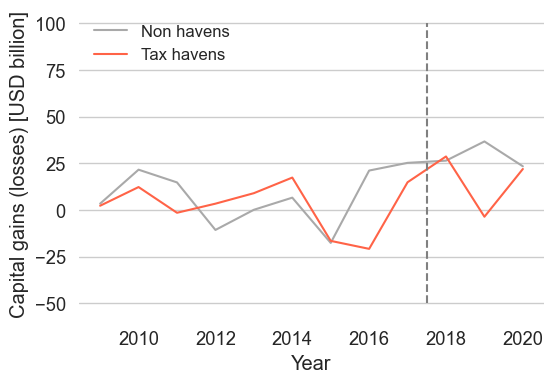

In [ ]:
plt.figure(figsize=(6,4))
x = bea_copy[["year","iso","capital_gains"]]
x["type"] = x["iso"].map(clas_count)
x["col"] = x["iso"].map(clas_count_col)
x = x.loc[x["iso"] != "Rest"]
x = x.loc[x["iso"] != "USA"]
x = x.loc[x["year"]>2008]
x = x.loc[x["year"]<2021]
x = x.groupby(["year","type","col"]).sum().reset_index().set_index("type")
for i in x.index.unique():
    plt.plot(x.loc[i, "year"], x.loc[i, "capital_gains"]/1E9, label=i, color=x.loc[i, "col"].values[0])
plt.legend()
plt.ylabel("Capital gains (losses) [USD billion]")
sns.despine(bottom=True, left=True)
plt.grid(axis="y")
plt.legend(frameon=False, fontsize=12)
# plt.legend(bbox_to_anchor=(1.05, 1), loc=1, borderaxespad=0.,frameon=False)
plt.plot([2017.5, 2017.5], [-50, 100],"--",color="gray")
plt.xlabel("Year")
plt.savefig(f"results/figures/capital_gains_evol.pdf",bbox_inches="tight")